In [1]:
!wget -nc https://zenodo.org/record/7041849/files/PapalexiSatija2021_eccite_RNA.h5ad
!wget -nc https://zenodo.org/record/7041849/files/PapalexiSatija2021_eccite_protein.h5ad
!pip install pyro-ppl graphviz seaborn anndata

File ‘PapalexiSatija2021_eccite_RNA.h5ad’ already there; not retrieving.

File ‘PapalexiSatija2021_eccite_protein.h5ad’ already there; not retrieving.



In [2]:
import multiprocessing

multiprocessing.cpu_count()

10

In [3]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import pyro
import scanpy as sc
import pyro.distributions as dist
from rs3.seq import predict_seq
from pyro.infer import (
    SVI,
    TraceEnum_ELBO,
    Trace_ELBO,
    TraceMeanField_ELBO,
    JitTraceEnum_ELBO,
    config_enumerate,
    infer_discrete,
)

from torch.utils.data import (
    Dataset,
    Sampler,
    DataLoader,
    WeightedRandomSampler,
    SubsetRandomSampler,
    BatchSampler,
)

from pyro.optim import Adam, ClippedAdam
from pyro.ops.indexing import Vindex

from pyro import poutine, render_model
from pyro.infer.autoguide import AutoNormal, AutoDelta, init_to_median, init_to_value
import sys
from tqdm import tqdm

if torch.cuda.is_available():
    print("Let's ride")
    device = "cuda"
    torch.set_float32_matmul_precision("high")
    # torch.set_default_device("cuda")
    smoke_test = False
else:
    device = "cpu"
    smoke_test = True
smoke_test = False


In [4]:
adata = ad.read_h5ad("PapalexiSatija2021_eccite_RNA.h5ad")
adata

AnnData object with n_obs × n_vars = 20729 × 18649
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [5]:
n_mito = adata[:, adata.var_names.str.startswith("MT-")].X.sum(axis=1).A1
n_rps = adata[:, adata.var_names.str.match("RPS[0-9]+")].X.sum(axis=1).A1
n_rpl = adata[:, adata.var_names.str.match("RPL[0-9]+")].X.sum(axis=1).A1
n_ribo = n_rps + n_rpl
n_total = adata.X.sum(axis=1).A1
# adata.obs
# plt.scatter(n_total, n_ribo, alpha=0.1)
# plt.scatter(n_total, n_mito, alpha=0.1)
# plt.scatter(n_ribo, n_mito, alpha=0.1)

In [6]:
adata.obs = adata.obs.assign(
    element=lambda x: x["perturbation"].str.replace("g[0-9]+$", "", regex=True)
)
adata.obs["element"]

AAACCTGAGCCAGAAC      STAT2
AAACCTGAGTGGACGT       CAV1
AAACCTGCATGAGCGA      STAT1
AAACCTGTCTTGTCAT       CD86
AAACGGGAGAACAACT       IRF7
                     ...   
TTTGTCAGTCACTTCC      CMTM6
TTTGTCAGTGACGGTA    control
TTTGTCAGTTCCACAA       ATF2
TTTGTCATCACGCATA       CAV1
TTTGTCATCTGTACGA      STAT3
Name: element, Length: 20729, dtype: object

In [7]:
adata.obs["guide_id"].str.replace("g[0-9]+$", "", regex=True)
adata.obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo,element
AAACCTGAGCCAGAAC,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942,STAT2
AAACCTGAGTGGACGT,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972,CAV1
AAACCTGCATGAGCGA,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583,STAT1
AAACCTGTCTTGTCAT,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997,CD86
AAACGGGAGAACAACT,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724,IRF7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586,CMTM6
TTTGTCAGTGACGGTA,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902,control
TTTGTCAGTTCCACAA,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673,ATF2
TTTGTCATCACGCATA,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578,CAV1


In [8]:
adata.layers["norm"] = sc.pp.normalize_total(adata, inplace=False)["X"]


In [9]:
layer = None
layer = "norm"
bc_name="bc"


target_genes = [g for g in adata.obs["element"].unique() if g != "control"]
print(str(len(target_genes)) + " target genes: " + " ".join(target_genes))

cell_elements = adata.obs[["element", "guide_id"]].reset_index(names=bc_name)

target_df = (
    adata[:, target_genes]
    .to_df(layer=layer)
    .melt(ignore_index=False)
    .reset_index(names=bc_name)
    .rename(columns={"gene_symbol": "element"})
    .assign(group="targeted")
)

target_expr = cell_elements.merge(target_df, how="inner").assign(
    guide_number=lambda x: x["guide_id"].str.replace(".+g", "", regex=True)
)


control_bcs = cell_elements.query("element=='control'").drop(columns="element")
control_expr = (
    adata[:, target_genes]
    .to_df(layer=layer)
    .melt(ignore_index=False)
    .reset_index(names=bc_name)
    .merge(control_bcs, on=[bc_name])
    .assign(guide_number=lambda x: "NT")
    .rename(columns={"gene_symbol": "element"})
    .assign(group="control")
)
# control_expr
# target_expr

control_and_target_expr = pd.concat((target_expr, control_expr), axis=0)
control_and_target_expr


25 target genes: STAT2 CAV1 STAT1 CD86 IRF7 ATF2 STAT3 JAK2 NFKBIA SMAD4 STAT5A CMTM6 IFNGR1 UBE2L6 PDCD1LG2 CUL3 BRD4 MARCH8 IRF1 POU2F2 ETV7 IFNGR2 TNFRSF14 SPI1 MYC


,bc,element,guide_id,value,group,guide_number
0,AAACCTGAGCCAGAAC,STAT2,STAT2g2,0.000000,targeted,2
1,AAACCTGAGTGGACGT,CAV1,CAV1g4,0.000000,targeted,4
2,AAACCTGCATGAGCGA,STAT1,STAT1g2,0.774449,targeted,2
3,AAACCTGTCTTGTCAT,CD86,CD86g1,0.000000,targeted,1
4,AAACGGGAGAACAACT,IRF7,IRF7g2,3.664323,targeted,2
...,...,...,...,...,...,...
59645,TTTCCTCTCAGCAACT,MYC,NTg2,0.000000,control,NT
59646,TTTGGTTGTTCCTCCA,MYC,NTg5,0.000000,control,NT
59647,TTTGGTTTCGACCAGC,MYC,NTg9,0.000000,control,NT
59648,TTTGTCAAGTTACGGG,MYC,NTg10,0.526492,control,NT


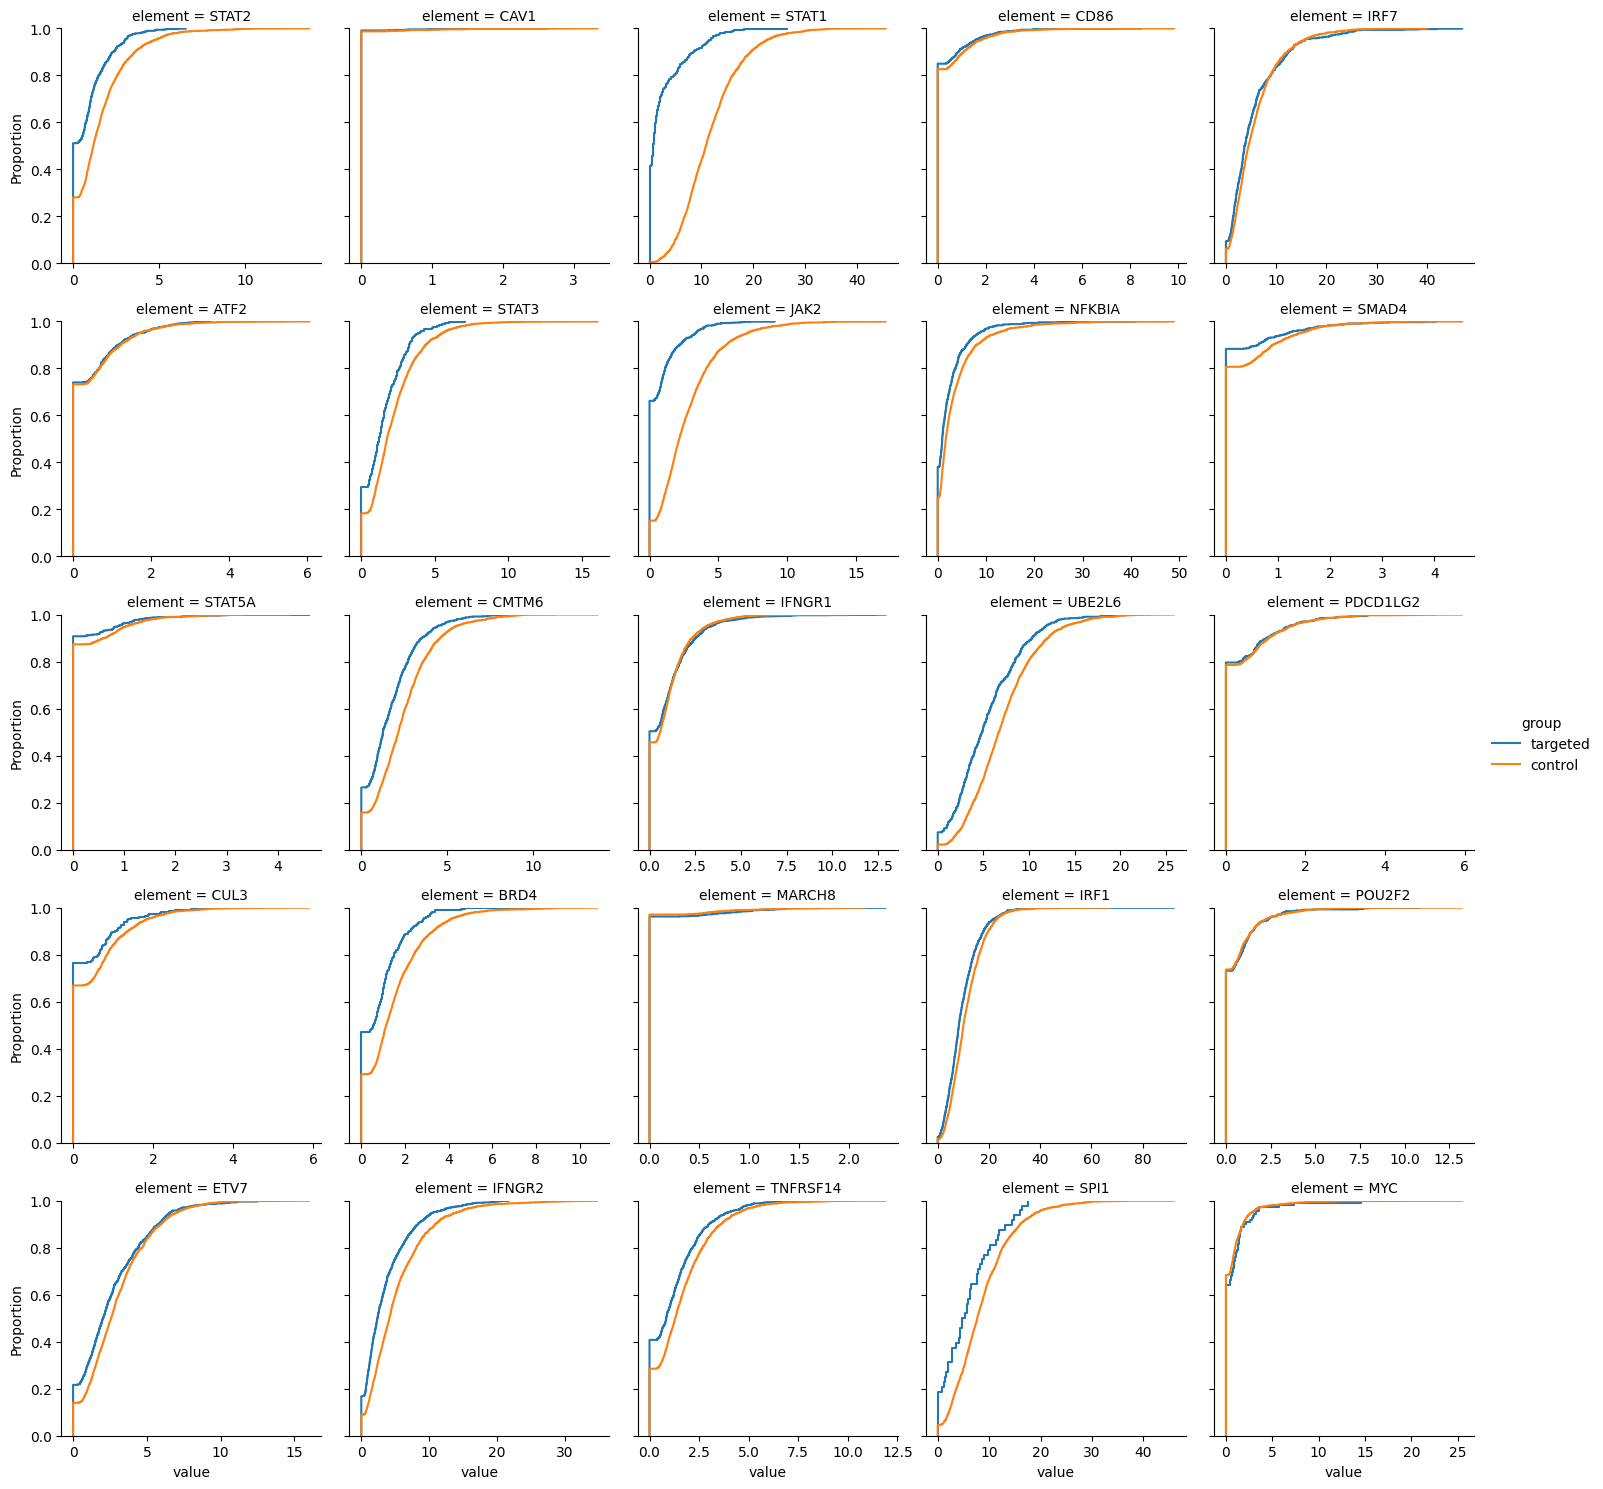

In [10]:
plot_type = sns.ecdfplot
# plot_type = sns.kdeplot

# Add other colors for the remaining guide_ids if needed
# For example, you can use the default Seaborn color palette for other guide_ids
# plot the ecdfs broken down by control vs. targeted
g = sns.FacetGrid(control_and_target_expr, col="element", hue="group", col_wrap=5, sharex=False, sharey=True)
g.map(plot_type, "value")
g.add_legend()
plt.show()


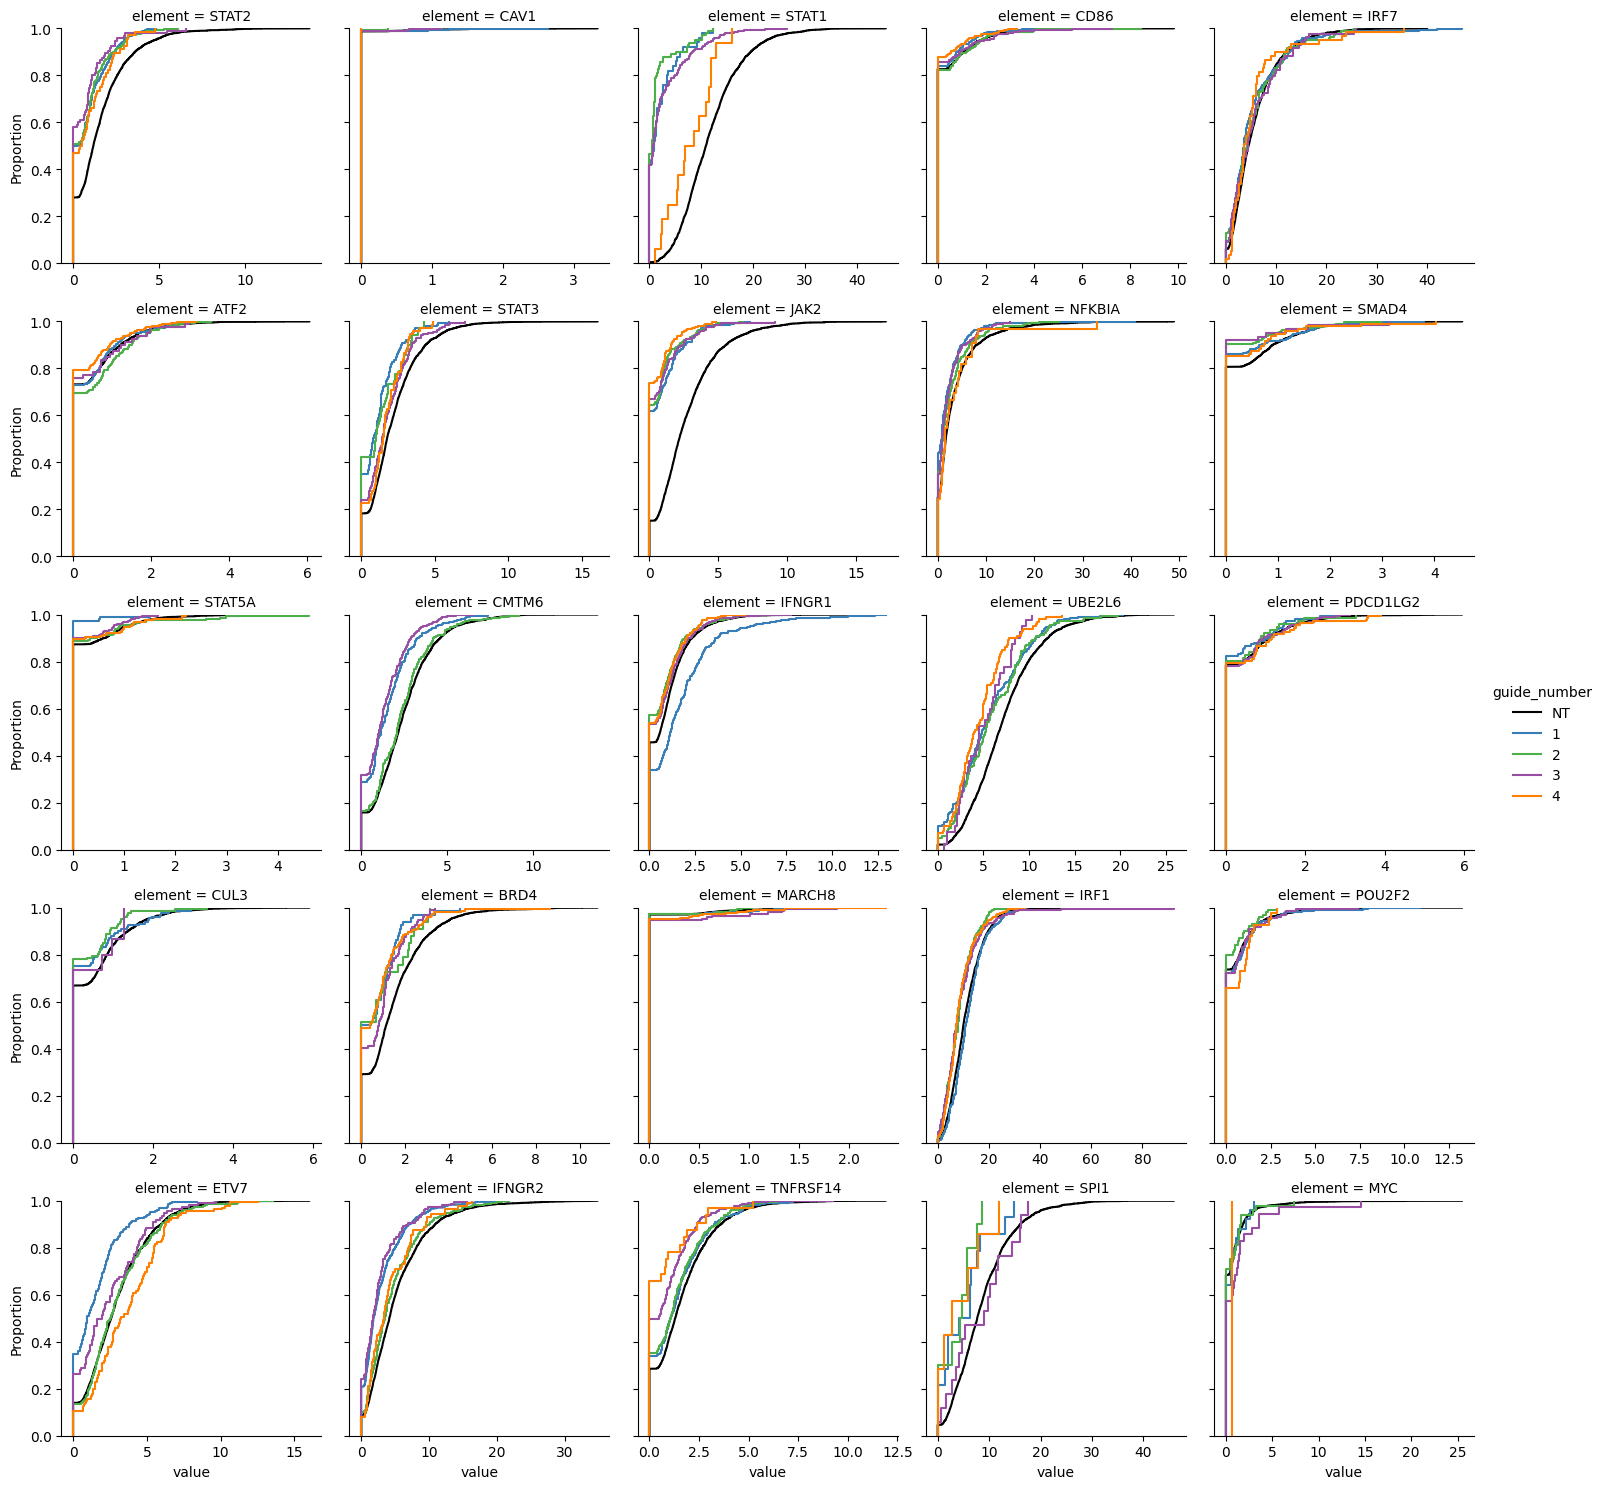

In [11]:
plot_type = sns.ecdfplot
# plot_type = sns.histplot

palette = sns.color_palette("Set1")
palette[0]="black"

# plot the ecdfs broken down by guide_id
g = sns.FacetGrid(
    control_and_target_expr,
    col="element",
    hue="guide_number",
    col_wrap=5,
    sharex=False,
    sharey=True,
    palette=palette,
    hue_order=["NT"]+[str(i) for i in range(1, 5)],
)

if plot_type==sns.histplot:
    g.map(plot_type, "value",common_norm=False,stat="density", bins=np.arange(0,20,step=1))
if plot_type == sns.kdeplot:
    raise ValueError("Kdeplot looks bad")
else:
    g.map(plot_type, "value")

g.add_legend()

plt.show()


In [50]:
plt.plot(prot_adata.X.sum(axis=1).A1, prot_adata.X.sum(axis=1).A1, 

array([2164606., 4011320., 1271680.,  906050.], dtype=float32)

In [12]:
prot_adata = ad.read_h5ad("PapalexiSatija2021_eccite_protein.h5ad")
prot_adata.var_names = prot_adata.var_names + "_protein"

In [43]:
prot_df = (
    prot_adata.to_df()
    .join(prot_adata.obs)
    .assign(element=lambda x: x["perturbation"].str.replace("g[0-9]+$", "", regex=True))
    .assign(targeted=lambda x: x["element"]!="control")
    .assign(guide_number=lambda x: x["perturbation"].str.replace("^.*g","",regex=True))
)
prot_df


,CD86_protein,PDL1_protein,PDL2_protein,CD366_protein,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,...,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo,element,targeted,guide_number
AAACCTGAGCCAGAAC,118.0,522.0,94.0,67.0,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,...,monocytes,human,1,4,801.0,0.0,0.0,STAT2,True,2
AAACCTGAGTGGACGT,243.0,139.0,104.0,59.0,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,...,monocytes,human,1,4,545.0,0.0,0.0,CAV1,True,4
AAACCTGCATGAGCGA,99.0,109.0,56.0,80.0,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,...,monocytes,human,1,4,344.0,0.0,0.0,STAT1,True,2
AAACCTGTCTTGTCAT,110.0,334.0,48.0,47.0,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,...,monocytes,human,1,4,539.0,0.0,0.0,CD86,True,1
AAACGGGAGAACAACT,303.0,593.0,77.0,80.0,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,...,monocytes,human,1,4,1053.0,0.0,0.0,IRF7,True,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,98.0,151.0,135.0,14.0,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,...,monocytes,human,1,4,398.0,0.0,0.0,CMTM6,True,1
TTTGTCAGTGACGGTA,1781.0,1117.0,89.0,55.0,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,...,monocytes,human,0,4,3042.0,0.0,0.0,control,False,control
TTTGTCAGTTCCACAA,84.0,73.0,38.0,17.0,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,...,monocytes,human,1,4,212.0,0.0,0.0,ATF2,True,1
TTTGTCATCACGCATA,18.0,135.0,37.0,68.0,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,...,monocytes,human,1,4,258.0,0.0,0.0,CAV1,True,2


NameError: name 'mdata' is not defined

25


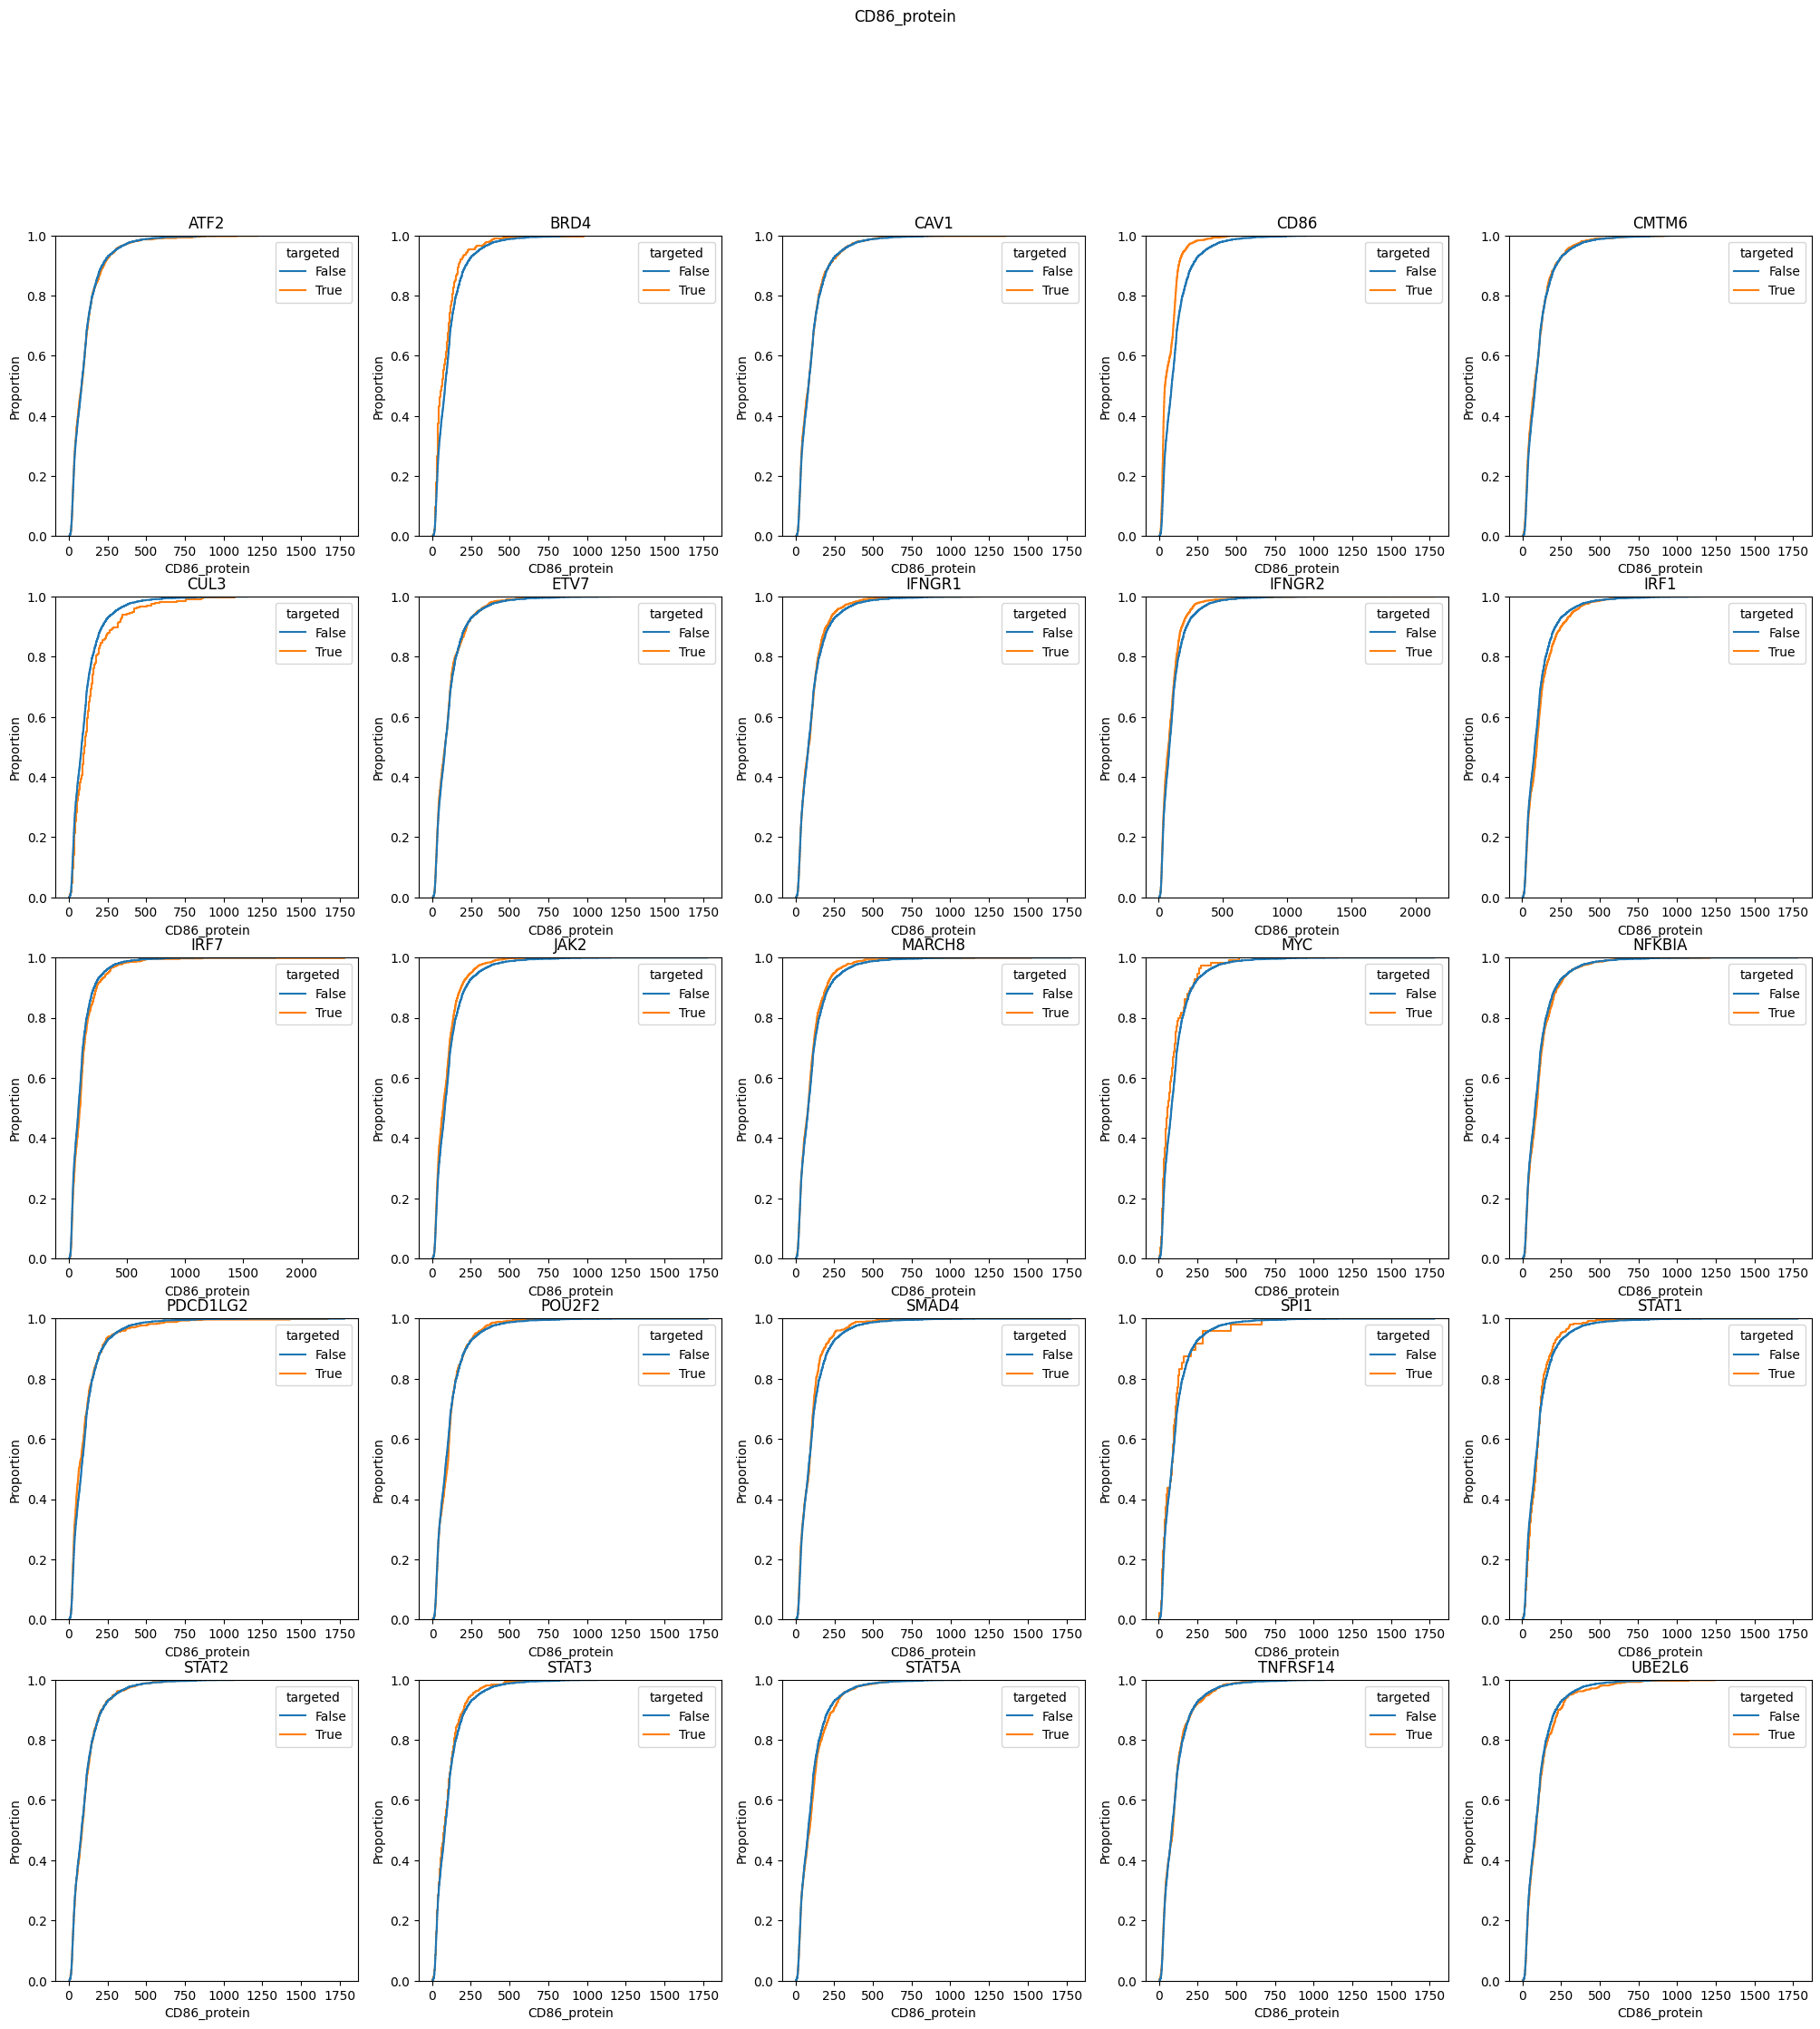

25


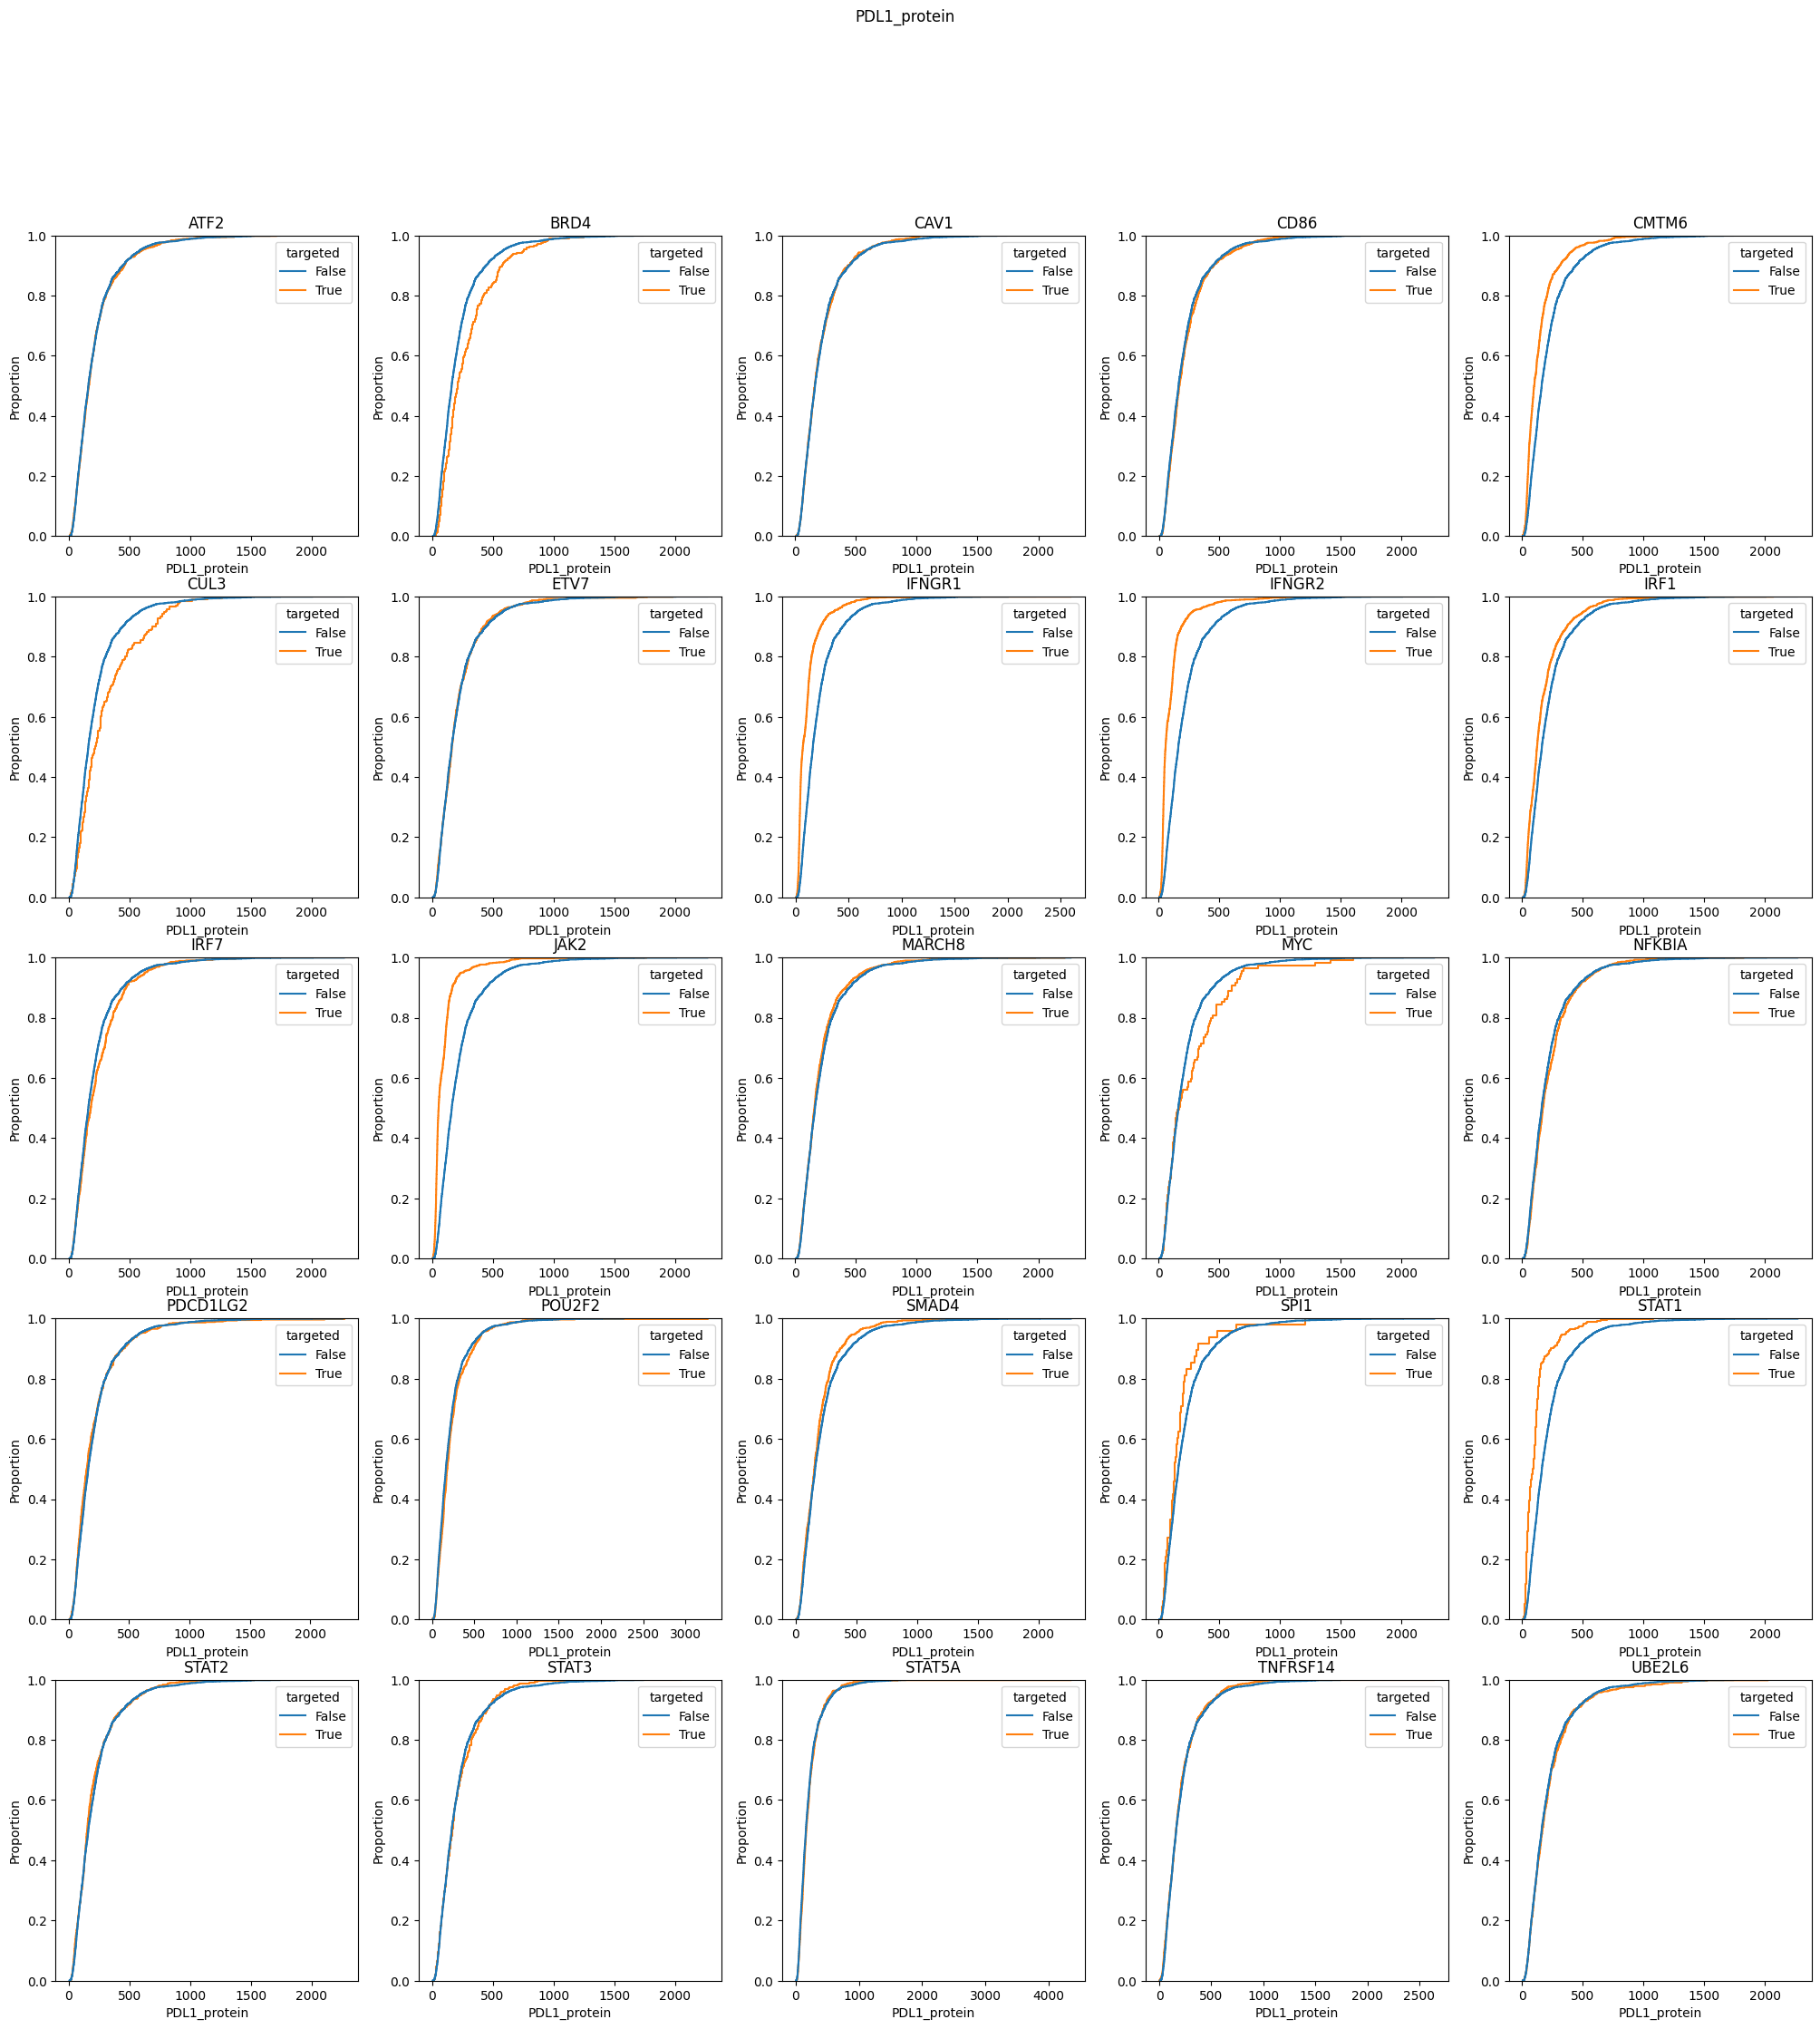

25


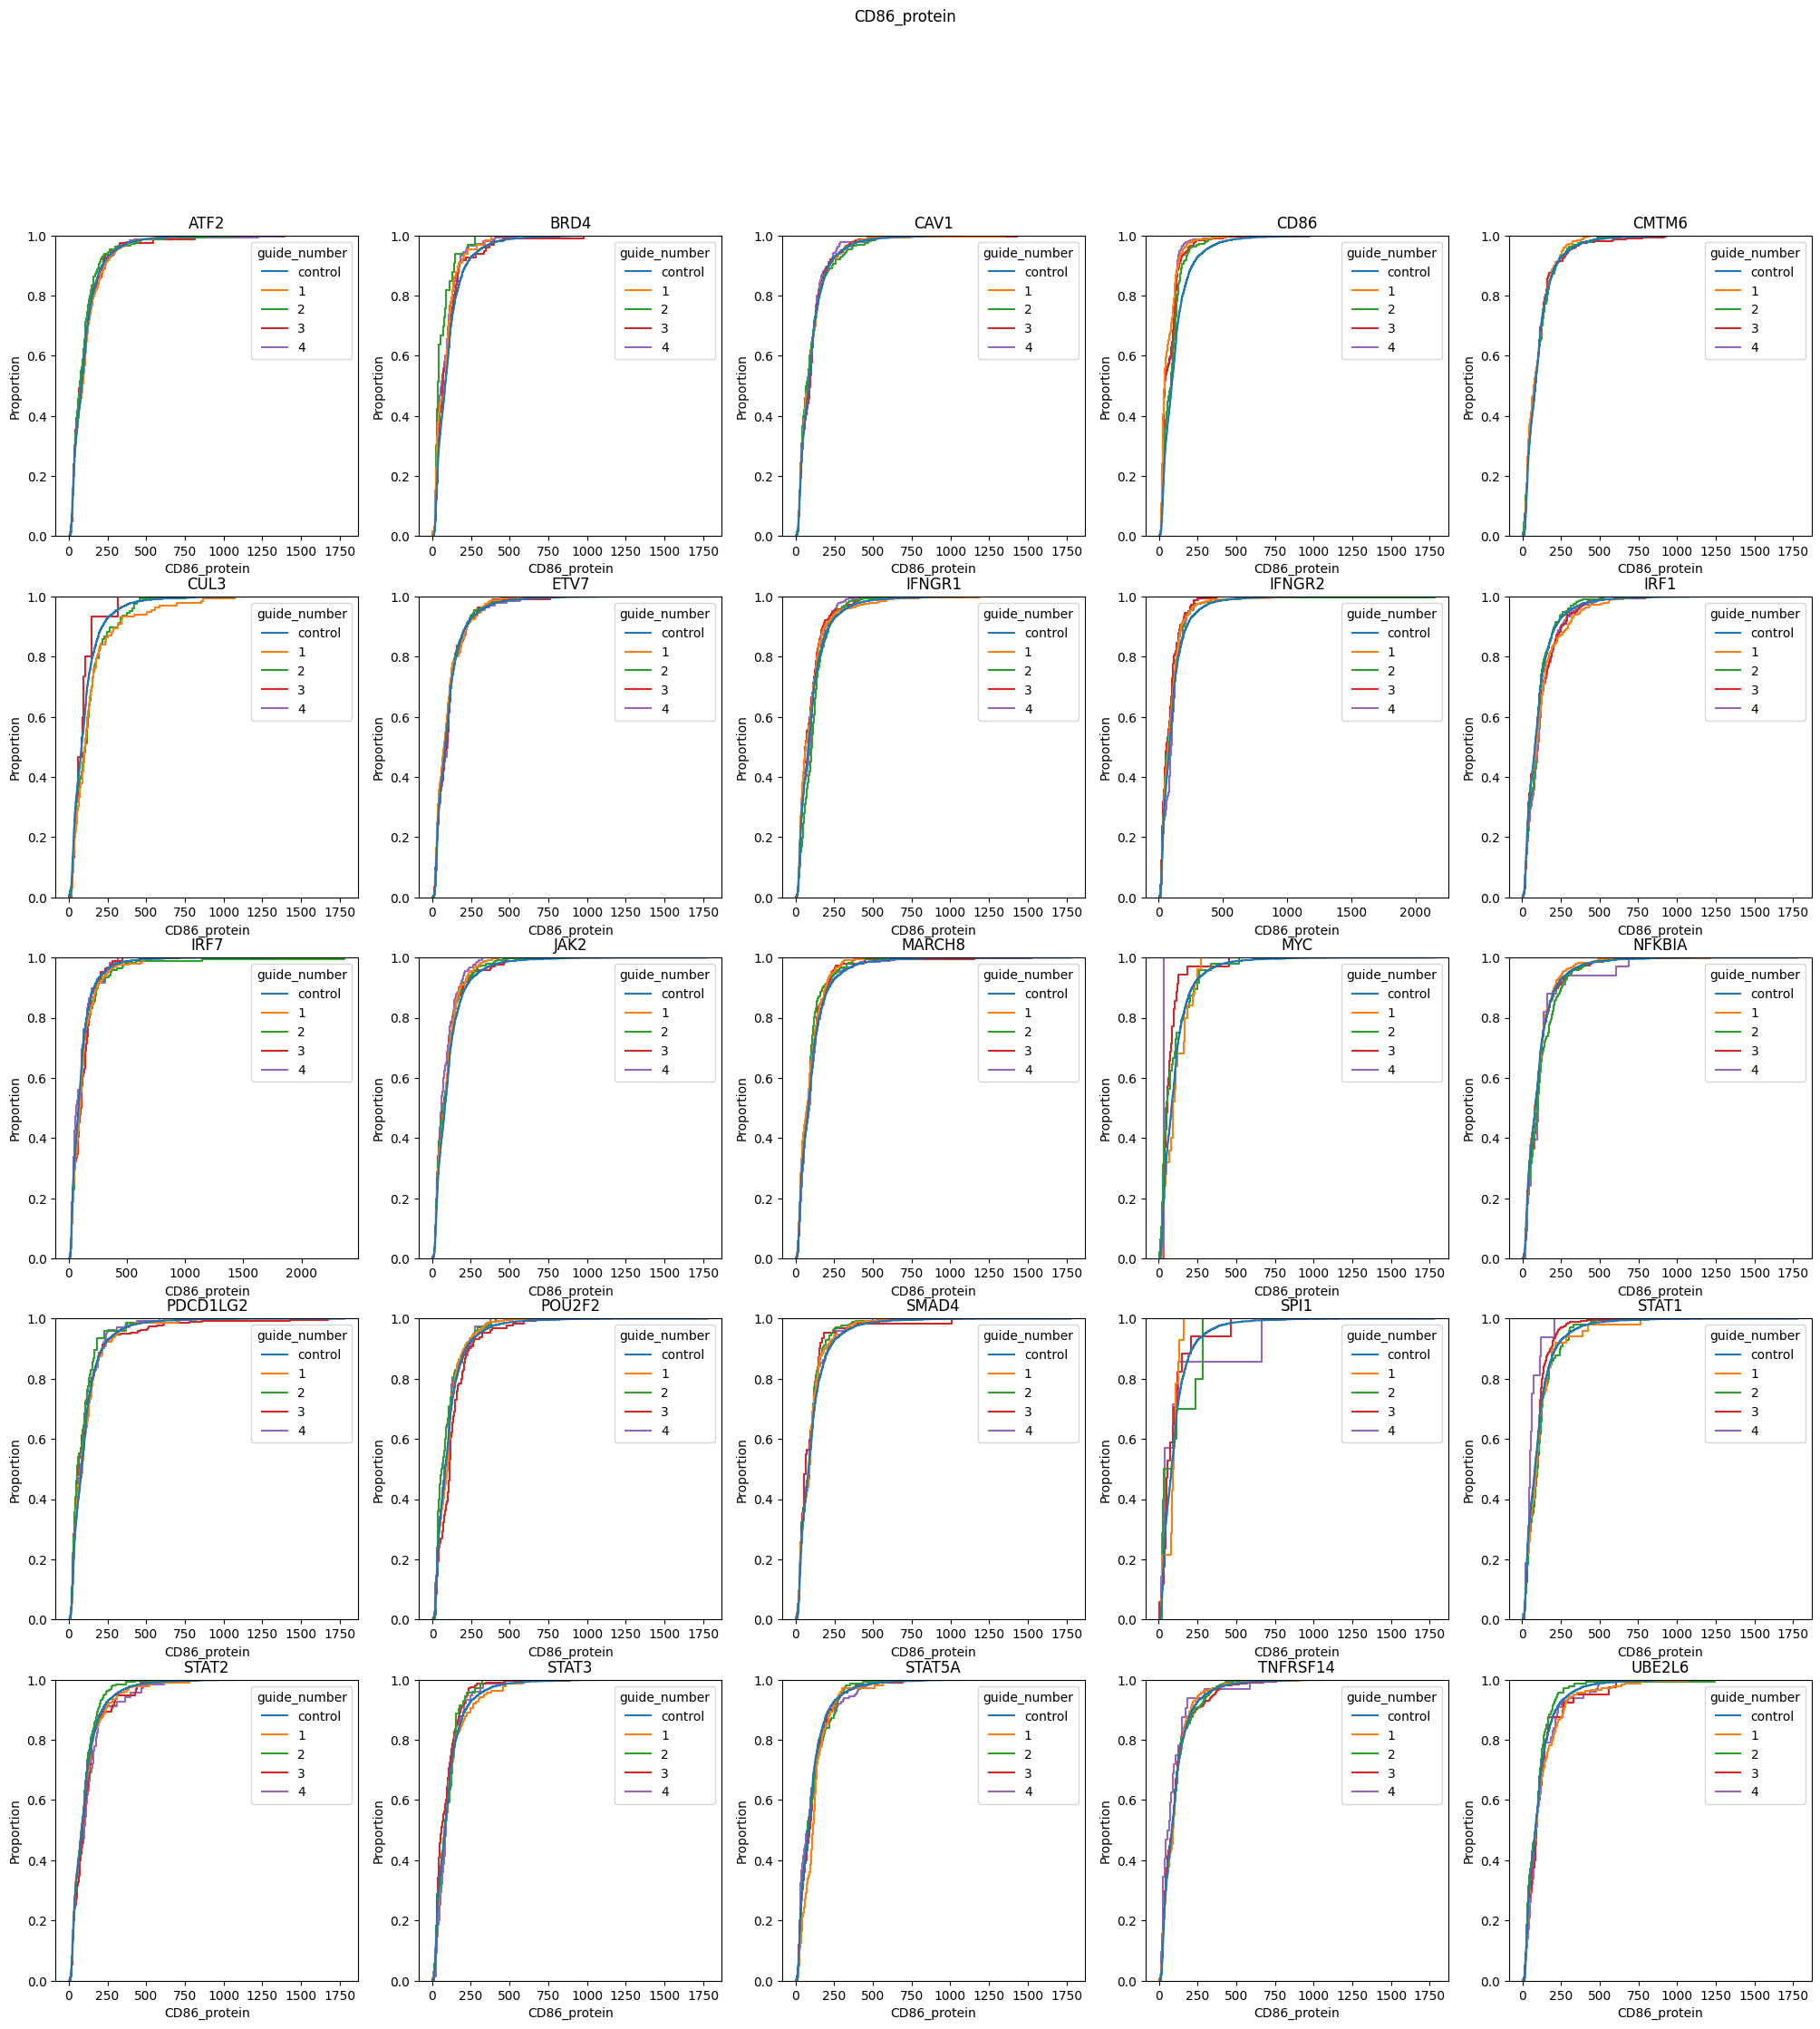

25


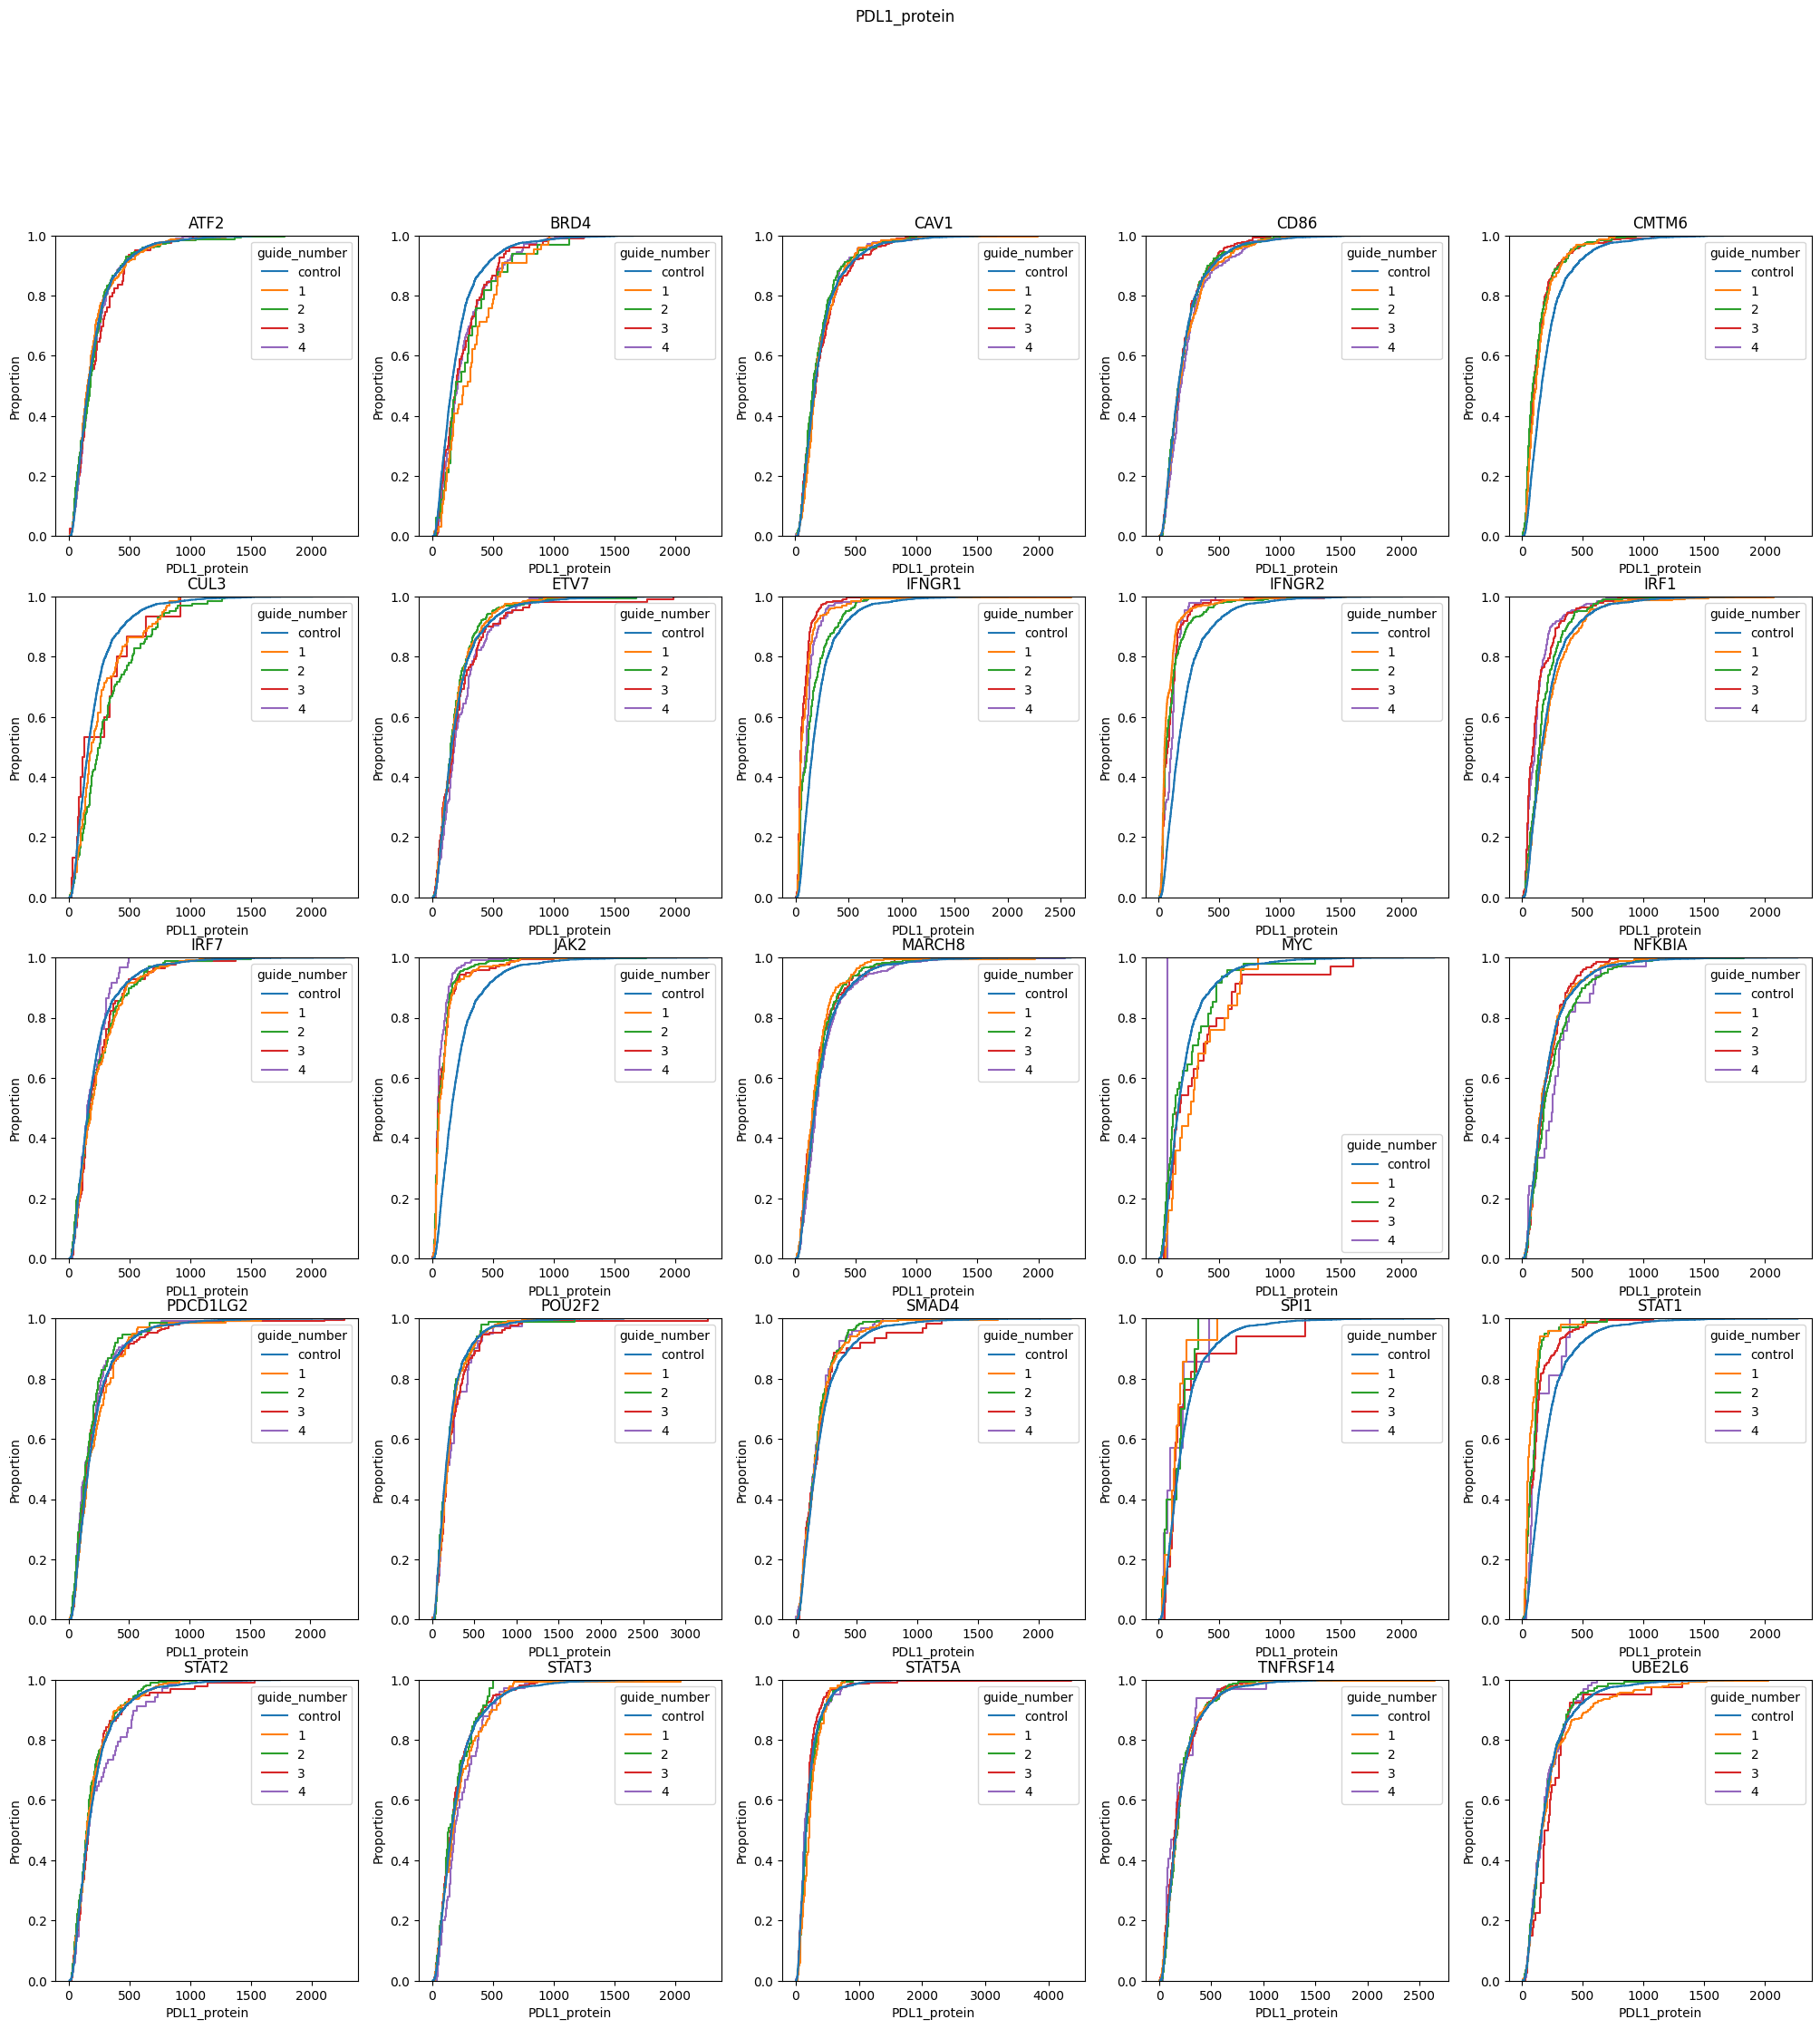

In [47]:
# prot_df
from math import ceil

for hue_column in ["targeted", "guide_number"]:
    for protein_column in ["CD86_protein", "PDL1_protein"]:
        # prot_df.melt(id_vars=["element"], value_vars=["PDL1_protein"])
        # prot_df[["guide_id", "element", "PDL1_protein"]]
        elements = sorted([x for x in prot_df["element"].unique() if x != "control"])
        print(len(elements))
        fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(25, 25))
        for ax, element in zip(axs.ravel(), elements):
            plot_data = prot_df.query(f"element=='{element}' or element=='control'")
            ax.set_title(element)
            sns.ecdfplot(
                plot_data,
                x=protein_column,
                hue=hue_column,
                ax=ax,
                hue_order=["control"] + [str(i) for i in range(1, 5)] if hue_column == "guide_number" else None,
            )
        fig.suptitle(protein_column)
        plt.show()


In [15]:
adata.obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo,element
AAACCTGAGCCAGAAC,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942,STAT2
AAACCTGAGTGGACGT,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972,CAV1
AAACCTGCATGAGCGA,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583,STAT1
AAACCTGTCTTGTCAT,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997,CD86
AAACGGGAGAACAACT,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724,IRF7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586,CMTM6
TTTGTCAGTGACGGTA,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902,control
TTTGTCAGTTCCACAA,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673,ATF2
TTTGTCATCACGCATA,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578,CAV1


In [16]:
# pick a subset of random genes including 3 known ones
# stat_target_genes = ["STAT1", "STAT2", "IRF1"]

# pick a subset of 50 genes including all perturbed ones
if smoke_test:
    n_genes_subset = 50
else:
    n_genes_subset = 1000
target_genes = [e for e in adata.obs["element"].unique() if e != "control"]
# target_genes += prot_adata.var_names.tolist()
hvg_rank = sc.pp.highly_variable_genes(adata, inplace=False, flavor="seurat_v3")
hvgs = hvg_rank.nlargest(n_genes_subset, "variances_norm").index
other_genes = [gene for gene in hvgs if gene not in target_genes]
selected_genes = target_genes + other_genes[: n_genes_subset - len(target_genes)]
# selected_genes = stat_target_genes + list(
#     np.random.choice(other_genes, size=n_genes_subset - len(stat_target_genes))
# )

# selected_guides = [f"STAT1g{i}" for i in range(1, 5)] + ["control"]
# guide_filter = adata.obs["perturbation"].isin(selected_guides)
# adata_subset = adata[guide_filter, :][:, selected_genes]
adata_subset = adata[:, selected_genes]

# else:
#     min_counts = 100 # min no. of cells with at least 1 count
#     selected_genes = ((adata.X>0).sum(axis=0)) > min_counts
#     adata_subset = adata[:, selected_genes]
# adata_subset

In [17]:
adata_subset.var_names

Index(['STAT2', 'CAV1', 'STAT1', 'CD86', 'IRF7', 'ATF2', 'STAT3', 'JAK2',
       'NFKBIA', 'SMAD4',
       ...
       'GALM', 'CCDC18', 'GBP7', 'ADAMTS5', 'SH2D2A', 'KIF22', 'STRA13',
       'IRS2', 'TKTL1', 'VWA5A'],
      dtype='object', name='gene_symbol', length=1000)

In [18]:
# from siphon.module import train
import mudata as md
grna_observed = pd.get_dummies(adata_subset.obs["guide_id"]).astype(int)

In [19]:
guide_by_element = (
    pd.crosstab(adata_subset.obs["guide_id"], adata_subset.obs["element"])
    .reindex(index=grna_observed.columns)
    > 0
).astype(int)

guide_by_element = guide_by_element.iloc[:,:-1] # remove control
guide_by_element

element,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,PDCD1LG2,POU2F2,SMAD4,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,UBE2L6
ATF2g1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BRD4g1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TNFRSF14g4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
UBE2L6g1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
UBE2L6g2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
UBE2L6g3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [20]:
n_elements = guide_by_element.shape[1]
gene_by_element = (
    pd.DataFrame(np.eye(n_elements), index=guide_by_element.columns, columns=guide_by_element.columns)
    .reindex(index=adata_subset.var_names)
    .fillna(0)
)
adata_subset.varm["element_targets"] = gene_by_element
adata_subset.varm["element_targets"]

/var/folders/w9/llll0v7j02zdytwd43sshysm0000gp/T/ipykernel_19853/1485371578.py:7: ImplicitModificationWarning: Setting element `.varm['element_targets']` of view, initializing view as actual.
  adata_subset.varm["element_targets"] = gene_by_element


element,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,PDCD1LG2,POU2F2,SMAD4,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,UBE2L6
gene_symbol,,,,,,,,,,,,,,,,,,,,,
STAT2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
CAV1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
STAT1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
CD86,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
IRF7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
KIF22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
STRA13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
IRS2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
# guide_metadata["gRNA sequence"].str.strip()


In [22]:
# from rs3.seq import predict_seq
# [len(s) for s in context_seqs]

<Axes: >

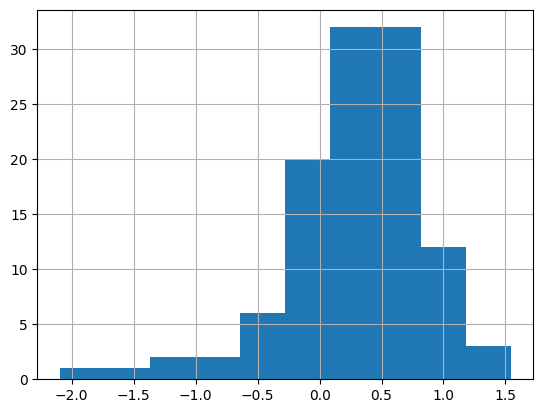

In [23]:
# from doenchScore import calcDoenchScore

guide_metadata = pd.read_csv("papalexi_guide_metadata.csv", index_col=0)

# guide_metadata["score"] = predict_seq(context_seqs, sequence_tracr="Chen2013")

# guide_metadata["rs1_score"] = [
#     calcDoenchScore("AAAC" + g + "CGGTGT") if g != "Non-Targeting" else -1 for g in guide_metadata["gRNA sequence"]
# ]
guide_metadata["rs3_score"].hist()

In [24]:
gdata = ad.AnnData(grna_observed, varm={"guide_targets": guide_by_element})
gdata.var = guide_metadata.loc[gdata.var_names]
mdata = md.MuData({"rna":adata_subset, "grna":gdata})
mdata

MuData object with n_obs × n_vars = 20729 × 1107
  2 modalities
    rna:	20729 x 1000
      obs:	'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'element'
      var:	'ensembl_id', 'ncounts', 'ncells'
      varm:	'element_targets'
      layers:	'norm'
    grna:	20729 x 107
      var:	'Gene', 'gRNA sequence', 'rs3_score'
      varm:	'guide_targets'

In [25]:
mdata["rna"].obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo,element
AAACCTGAGCCAGAAC,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942,STAT2
AAACCTGAGTGGACGT,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972,CAV1
AAACCTGCATGAGCGA,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583,STAT1
AAACCTGTCTTGTCAT,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997,CD86
AAACGGGAGAACAACT,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724,IRF7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586,CMTM6
TTTGTCAGTGACGGTA,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902,control
TTTGTCAGTTCCACAA,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673,ATF2
TTTGTCATCACGCATA,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578,CAV1


In [26]:
mdata["rna"].varm["element_targets"]
mdata["rna"].varm["guide_targets"] = mdata["rna"].varm["element_targets"] @ mdata["grna"].varm["guide_targets"].T
mdata["grna"].varm["guide_identity"] = pd.DataFrame(
    np.eye(mdata["grna"].n_vars),
    index=mdata["grna"].var_names,
    columns=mdata["grna"].var_names,
)

# Remove NT guides
mdata["grna"].varm["guide_identity"] = (
    mdata["grna"].varm["guide_identity"].loc[:, ~mdata["grna"].varm["guide_identity"].columns.str.startswith("NT")]
)

targeting_guides = mdata["grna"].var_names[~mdata["grna"].var_names.str.startswith("NT")]

mdata["rna"].varm["guide_targets"] = mdata["rna"].varm["guide_targets"][targeting_guides]
mdata["grna"].varm["guide_identity"] = mdata["grna"].varm["guide_identity"][targeting_guides]
# mdata["rna"].varm["guide_targets"]
assert (mdata["grna"].varm["guide_identity"].columns == mdata["rna"].varm["guide_targets"].columns).all()

# break

In [27]:
import perturbo

# perturbo.PERTURBO.setup_mudata(
#     mdata,
#     batch_key="hto",
#     library_size_key="ncounts",
#     continuous_covariates_keys=["percent_mito", "percent_ribo"],
#     guide_by_element_key="guide_targets",
#     gene_by_element_key="element_targets",
#     modalities={
#         "rna_layer": "rna",
#         "perturbation_layer": "grna",
#     },
# )

perturbo.PERTURBO.setup_mudata(
    mdata,
    batch_key="hto",
    library_size_key="ncounts",
    continuous_covariates_keys=["percent_mito", "percent_ribo"],
    guide_by_element_key="guide_identity",
    # gene_by_element_key="guide_targets",
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

n_factors = 10 if not smoke_test else 2
n_pert_factors = 20 if not smoke_test else 10

# model = perturbo.PERTURBO(
#     mdata,
#     likelihood="nb",
#     efficiency_mode="mixture",
#     n_factors=2,
#     use_interactions=False,
#     n_pert_factors=20,
# )

# model = perturbo.PERTURBO(
#     mdata,
#     likelihood="lnnb",
#     efficiency_mode="mixture",
#     n_factors=10 if not smoke_test else 2,
#     # use_interactions=True,
#     # use_crispr_factor=True,
#     # prior_param_dict={"logit_efficacy_alpha": torch.tensor(1.0)},
#     n_pert_factors=20 if not smoke_test else 10,
# )

# model = perturbo.PERTURBO(
#     mdata,
#     likelihood="nb",
#     efficiency_mode="scaled",
#     merge_guides_mode="shared",
#     n_factors=n_factors,
#     n_pert_factors=n_pert_factors,
# )

model = perturbo.PERTURBO(
    mdata,
    likelihood="lnnb",
    efficiency_mode="scaled",
    merge_guides_mode="shared",
    n_factors=None,
    n_pert_factors=None,
)

# model = perturbo.PERTURBO(mdata, likelihood="nb", efficiency_mode="mixture", n_factors=5, n_pert_factors=20)
# model = perturbo.PERTURBO(
#     mdata,
#     likelihood="nb",
#     efficiency_mode="mixture",
#     n_factors=5,
#     n_pert_factors=10,
#     merge_guides_mode="partial",
# )

model.view_anndata_setup()


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


INFO     Using column names from columns of adata.varm['guide_identity']                                           


<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:101: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self

Anndata setup with scvi-tools version 1.0.4.

Setup via `PERTURBO.setup_anndata` with arguments:

...

        Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch         │   5   │
│         n_cells         │ 20729 │
│ n_extra_continuous_covs │   2   │
│  n_gene_summary_stats   │   1   │
│     n_perturbations     │  107  │
│   n_targeted_elements   │  98   │
│         n_vars          │ 1000  │
└─────────────────────────┴───────┘

                                 Data Registry                                  
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃                 scvi-tools Location                  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.mod['rna'].X                  │
│         batch         │         adata.mod['rna'].obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.mod['rna'].obsm['_scvi_extra_continuous_covs'] │
│  gene_summary_stats   │  adata.mod['rna'].varm['_scvi_gene_summary_stats']   │
│         ind_x         │            adata.mod['rna'].obs['_ind_x']            │
│     perturbations     │                 adata.mod['grna'].X                  │
│      size_factor      │         adata.mod['rna'].obs['_size_factor']         │
│   targeted_elements   │       adata.mod['grna'].varm['guide_identity']       │
└───────────────────────┴──────────────────────────────────────────────────────┘

                 batch State Registry                  
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Source Location  ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['hto'] │  rep1-tx   │          0          │
│                  │ rep2-ctrl  │          1          │
│                  │  rep2-tx   │          2          │
│                  │  rep3-tx   │          3          │
│                  │  rep4-tx   │          4          │
└──────────────────┴────────────┴─────────────────────┘

 gene_summary_stats State  
         Registry          
┏━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location     ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.var['_gene_mean'] │
└─────────────────────────┘

 extra_continuous_covs State 
          Registry           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['percent_mito'] │
│ adata.obs['percent_ribo'] │
└───────────────────────────┘

(array([ 12.,  19.,  29.,  28.,  30.,  57., 101.,  97.,  89., 108., 132.,
        105., 122., 115., 120., 153., 161., 167., 162., 221., 238., 206.,
        232., 225., 239., 285., 303., 281., 319., 342., 333., 375., 341.,
        394., 412., 384., 441., 439., 431., 457., 475., 483., 515., 459.,
        454., 519., 493., 473., 486., 473., 470., 454., 463., 430., 429.,
        389., 380., 361., 352., 314., 305., 297., 263., 224., 212., 215.,
        214., 193., 165., 157., 109., 127., 115.,  96.,  83.,  65.,  55.,
         53.,  29.,  31.,  30.,  32.,  13.,  15.,   6.,   9.,   9.,   8.,
          7.,   4.,   4.,   0.,   3.,   2.,   0.,   1.,   0.,   0.,   0.,
          1.]),
 array([-1.36212379, -1.33028825, -1.29845271, -1.26661717, -1.23478163,
        -1.20294609, -1.17111055, -1.13927501, -1.10743947, -1.07560393,
        -1.04376839, -1.01193285, -0.98009731, -0.94826177, -0.91642623,
        -0.88459069, -0.85275515, -0.82091961, -0.78908407, -0.75724853,
        -0.72541299, -0.69

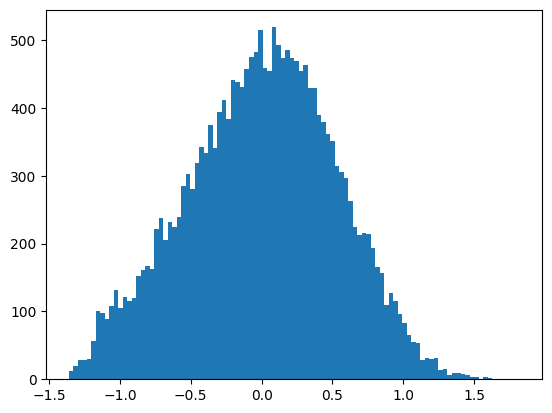

In [28]:
plt.hist(mdata["rna"].obs["_size_factor"], bins=100)


In [29]:
(model.module.guide_by_element.sum(dim=1) > 0).shape

torch.Size([107])

## Set model parameters and train

In [30]:
model.train(
    1000,
    lr=0.01,
    batch_size=1024,
    # callbacks=[checkpoint_callback],
    # enable_checkpointing=True,
    early_stopping=True,
    early_stopping_patience=10,
    early_stopping_min_delta=1e-2,
    early_stopping_monitor="elbo_train",
)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 137/1000:  14%|█▎        | 137/1000 [13:16<1:23:35,  5.81s/it, v_num=1, elbo_train=1.75e+7]
Monitored metric elbo_train did not improve in the last 10 records. Best score: 17520040.000. Signaling Trainer to stop.


In [31]:
if "crispr_loading" in model.module.guide.median():
    crispr_loading_mu = model.module.guide.median()["crispr_loading"].squeeze().T.numpy()
    crispr_loading_sigma = (
        crispr_loading_mu - model.module.guide.quantiles([0.17])["crispr_loading"].squeeze().T.numpy()
    )
    crispr_loading_df = pd.DataFrame(
        crispr_loading_mu / crispr_loading_sigma, index=mdata["rna"].var_names, columns=["value"]
    )
    print(crispr_loading_df.sort_values("value").head(20))

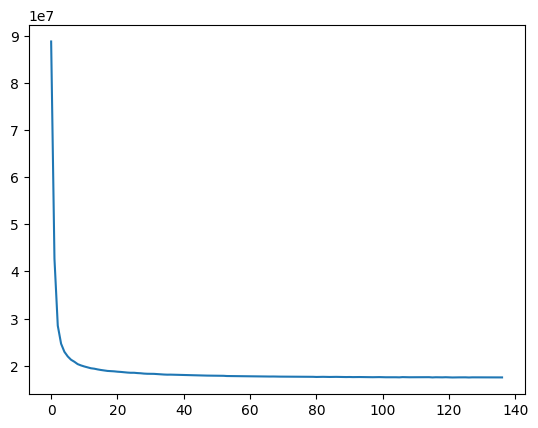

In [32]:
plt.plot(model.history["elbo_train"])

## Inference Results

In [33]:
model.module.guide.median().keys()

dict_keys(['log_gene_mean', 'log_gene_dispersion', 'multiplicative_noise', 'batch_effect', 'cont_covariate_effect', 'element_effects'])

In [34]:
import scanpy as sc
# pyro.get_param_store["cell_factors"].shape
if "cell_factors" in model.module.guide.median():
    cell_factors = model.module.guide.median()["cell_factors"].squeeze().T.numpy()
    # cell_factors = pyro.get_param_store()["AutoGuideList.1.cell_factors"].detach().squeeze().T.numpy()
    mdata["rna"].obsm["X_ppca"] = cell_factors
    sc.pl.embedding(mdata["rna"], basis="X_ppca", color="hto", sort_order=False)

In [35]:
if "cell_loadings" in model.module.guide.median():
    loadings_df = pd.DataFrame(model.module.guide.median()["cell_loadings"].squeeze(), columns=mdata["rna"].var_names)
    print(loadings_df)

In [36]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)


AutoGuideList.0.locs.log_gene_mean torch.Size([1000])
AutoGuideList.0.scales.log_gene_mean torch.Size([1000])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([1000])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([1000])
AutoGuideList.0.locs.multiplicative_noise torch.Size([1000])
AutoGuideList.0.scales.multiplicative_noise torch.Size([1000])
AutoGuideList.0.locs.batch_effect torch.Size([5, 1000])
AutoGuideList.0.scales.batch_effect torch.Size([5, 1000])
AutoGuideList.0.locs.cont_covariate_effect torch.Size([3, 1000])
AutoGuideList.0.scales.cont_covariate_effect torch.Size([3, 1000])
perturbo$$$_guide.0.locs.log_gene_mean_unconstrained torch.Size([1000])
perturbo$$$_guide.0.locs.log_gene_dispersion_unconstrained torch.Size([1000])
perturbo$$$_guide.0.locs.multiplicative_noise_unconstrained torch.Size([1000])
perturbo$$$_guide.0.locs.batch_effect_unconstrained torch.Size([5, 1000])
perturbo$$$_guide.0.locs.cont_covariate_effect_unconstrained torch.Size([3, 1000])
perturbo$$$_

In [37]:
# plt.scatter(siphon_model.dataset.size_factor, siphon_model.guide.median()["size_factor_fit"], alpha=0.01)

In [38]:
# plt.plot(losses)

In [39]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)

AutoGuideList.0.locs.log_gene_mean torch.Size([1000])
AutoGuideList.0.scales.log_gene_mean torch.Size([1000])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([1000])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([1000])
AutoGuideList.0.locs.multiplicative_noise torch.Size([1000])
AutoGuideList.0.scales.multiplicative_noise torch.Size([1000])
AutoGuideList.0.locs.batch_effect torch.Size([5, 1000])
AutoGuideList.0.scales.batch_effect torch.Size([5, 1000])
AutoGuideList.0.locs.cont_covariate_effect torch.Size([3, 1000])
AutoGuideList.0.scales.cont_covariate_effect torch.Size([3, 1000])
perturbo$$$_guide.0.locs.log_gene_mean_unconstrained torch.Size([1000])
perturbo$$$_guide.0.locs.log_gene_dispersion_unconstrained torch.Size([1000])
perturbo$$$_guide.0.locs.multiplicative_noise_unconstrained torch.Size([1000])
perturbo$$$_guide.0.locs.batch_effect_unconstrained torch.Size([5, 1000])
perturbo$$$_guide.0.locs.cont_covariate_effect_unconstrained torch.Size([3, 1000])
perturbo$$$_

In [40]:
guide=model.module.guide
guides = mdata["grna"].var_names
elements = guide_by_element.index
guide.median().keys()

dict_keys(['log_gene_mean', 'log_gene_dispersion', 'multiplicative_noise', 'batch_effect', 'cont_covariate_effect', 'element_effects'])

In [41]:
guides = guide_by_element.index
elements = guide_by_element.columns
plt.figure(figsize=(20, 4))
if "guide_efficacy" in guide.median():
    element_efficiency = pd.DataFrame(
        guide.median()["guide_efficacy"].detach().cpu(),
        index=guides,
        columns=["efficiency"],
    ).reset_index(names="element")
    element_efficiency
    sns.barplot(element_efficiency, x="element", y="efficiency")
    plt.xticks(rotation=90)

<Figure size 2000x400 with 0 Axes>

In [42]:
if "guide_efficacy" in guide.median():
    median_efficiency = pd.DataFrame(
        guide.median()["guide_efficacy"].detach().cpu(),
        index=guides,
        columns=["efficiency"],
    ).assign(
        guide=lambda x: x.index,
        element=lambda x: x.index.str.replace("g[0-9]+$", "", regex=True),
    )
    median_efficiency.hist("efficiency")
    plt.show()
    sns.stripplot(median_efficiency, x="element", y="efficiency")
    plt.xticks(rotation=90)

In [43]:
effects_df_long = model.get_element_effects()
effects_df_long

,element,gene,loc,scale,z_value,q_value
39426,IFNGR2g1,HLA-DRA,-2.056138,0.045528,-45.161640,0.000000e+00
87152,IFNGR2g1,CD74,-1.795913,0.040681,-44.146374,0.000000e+00
87150,IFNGR1g3,CD74,-1.956589,0.047467,-41.220207,0.000000e+00
1794,IFNGR2g1,IRF1,-1.381947,0.041956,-32.938179,6.247096e-238
85682,IFNGR2g1,SOCS1,-2.048236,0.062854,-32.587227,6.221378e-233
...,...,...,...,...,...,...
83367,SMAD4g2,CTSG,1.325944,0.081986,16.172762,7.849890e-59
2977,IRF1g4,C1QC,2.959590,0.182526,16.214581,3.977829e-59
4153,IRF1g4,CXCL9,2.100794,0.124007,16.940912,2.246144e-64
53741,IRF1g4,STEAP4,2.107534,0.120448,17.497446,1.498393e-68


In [90]:
effect_key="loc"
effect_key="z_value"
effects_df = effects_df_long.pivot_table(values=effect_key, index="element", columns="gene").fillna(0)
effects_df

gene,A2M,ABCA13,ABCG1,AC003092.1,AC006967.1,AC010649.1,AC016735.2,AC074289.1,AC079466.1,AC092484.1,...,XBP1,XIRP1,XIST,ZFAND2A,ZFP36,ZFP36L1,ZNF486,ZNF503,ZWINT,eGFP
element,,,,,,,,,,,,,,,,,,,,,
ATF2g1,-0.807823,-0.573508,0.348300,1.114780,-0.348866,0.730816,-1.153376,0.332106,0.057286,-0.993487,...,1.806388,-0.240755,-0.534546,-1.638253,0.851898,-2.861978,-0.117743,-1.263712,-0.446339,0.288334
ATF2g2,-0.382553,-0.262502,0.233589,0.321995,-0.506123,-0.141235,-1.170311,-0.151366,-0.211745,0.241848,...,-1.220719,2.944336,2.036994,-1.096274,0.205203,-0.403464,-0.276794,-0.059618,0.223387,-1.860873
ATF2g3,-0.368763,-0.192056,0.454282,-0.306528,-0.117468,-0.526413,1.242981,-0.655681,-0.057593,-0.421267,...,2.148004,0.080901,-0.082429,-0.508924,-2.063432,0.327750,-0.062946,1.524084,-0.524167,-0.914456
ATF2g4,0.578864,-0.347888,-0.170004,0.909064,0.722165,0.326307,-1.310055,-0.242980,0.431278,-0.484171,...,0.573733,-0.868263,-0.220188,-3.130136,0.722173,0.068105,-0.332934,0.064649,1.308135,1.794337
BRD4g1,-0.214947,-0.078194,-0.803894,-0.253691,-0.238303,-0.182576,-1.088881,-0.490343,-0.071218,-0.088251,...,-3.142503,0.923433,-0.044435,-1.669860,-0.251915,-1.776744,-0.063888,-0.047047,-0.680787,-0.166470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TNFRSF14g4,-0.840624,-0.113886,0.050854,0.768559,-0.036593,-0.210523,-0.626236,-0.223241,-0.022747,-0.116638,...,0.560374,-0.137681,-0.014886,2.585681,1.683808,-1.690529,0.022200,1.034313,-0.454704,-1.930414
UBE2L6g1,1.414021,-0.248810,-1.020886,-0.175507,0.191235,-0.530215,-0.819225,-0.961887,-0.223385,0.804640,...,1.158064,0.761363,-0.367025,0.364452,-2.017807,-0.767296,-0.523216,-1.127909,-0.824313,0.872614
UBE2L6g2,0.077357,-0.251197,0.605073,-0.672812,-0.282885,-0.368310,0.491290,-0.934303,-0.096262,-0.763105,...,1.124007,0.540145,-0.320678,0.490688,1.204387,1.060259,-0.168328,-0.199650,0.233270,0.537461


In [105]:
cis_effects = (
    effects_df_long.assign(guide_number=lambda x: x["element"].str.replace(".+g", "", regex=True))
    .assign(target=lambda x: x["element"].str.replace("g[0-9]+$", "", regex=True))
    .query("target==gene")
)
# cis_effects = effects_df_long.query("element==gene")
cis_effects

,element,gene,loc,scale,z_value,q_value,guide_number,target
272,STAT1g3,STAT1,-1.566563,0.051279,-30.549543,5.734128e-205,3,STAT1
271,STAT1g2,STAT1,-2.056816,0.089334,-23.023993,2.680829e-117,2,STAT1
2088,IFNGR2g1,IFNGR2,-0.518337,0.031299,-16.561003,1.333527e-61,1,IFNGR2
729,JAK2g2,JAK2,-1.320137,0.081320,-16.233835,2.907126e-59,2,JAK2
270,STAT1g1,STAT1,-1.619356,0.105463,-15.354774,3.290511e-53,1,STAT1
...,...,...,...,...,...,...,...,...
1715,MARCH8g4,MARCH8,0.452636,0.221099,2.047214,4.063707e-02,4,MARCH8
1714,MARCH8g3,MARCH8,0.698021,0.338990,2.059119,3.948282e-02,3,MARCH8
2404,MYCg3,MYC,0.640077,0.257487,2.485860,1.292389e-02,3,MYC
1985,ETV7g4,ETV7,0.218618,0.071420,3.061018,2.205862e-03,4,ETV7


In [106]:
# plot_genes = cis_effects.nsmallest()
from scipy.stats import pearsonr, spearmanr

if "guide_efficacy" in guide.median():
    mdata["grna"].var = mdata["grna"].var.assign(
        inferred_efficacy=guide.median()["guide_efficacy"].detach().cpu(),
    )

    # plot_genes=["STAT1","JAK2","NFKBIA"]
    # plot_data = mdata["grna"].var[mdata["grna"].var["Gene"].isin(plot_genes)]
    plot_data = mdata["grna"].var

    g = sns.scatterplot(plot_data, x="rs3_score", y="inferred_efficacy", hue="Gene")
    sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
    plot_data.sort_values("inferred_efficacy")
    spearmanr(plot_data["rs3_score"], plot_data["inferred_efficacy"])
    # mdata["grna"].var

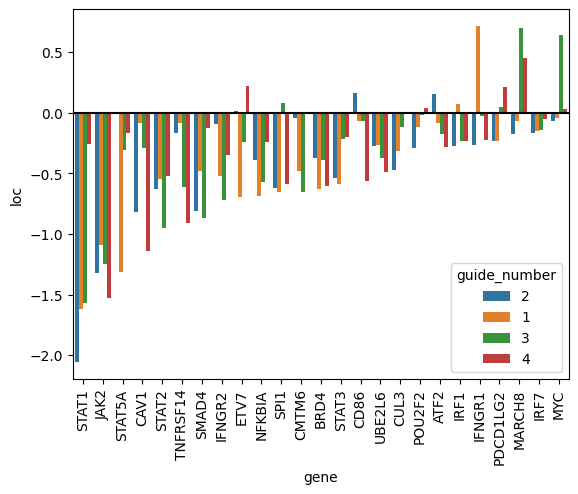

In [107]:
# median_cis_effect = guide.median()["cis_effect"].detach().cpu()
# low_cis_effect, high_cis_effect = (
    # guide.quantiles([0.159, 0.841])["cis_effect"].detach().cpu()
# )
# sigma_cis_effect = high_cis_effect - median_cis_effect
# z_score_cis_effect = median_cis_effect / sigma_cis_effect
# key="z_value"
key="loc"
sns.barplot(cis_effects.sort_values(key), x="gene", hue="guide_number", y=key)
plt.axhline(0, color="black")
plt.xticks(rotation=90)
plt.show()

# sns.barplot(x=elements, y=z_score_cis_effect.squeeze())

# plt.xticks(rotation=90)
# plt.show()

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


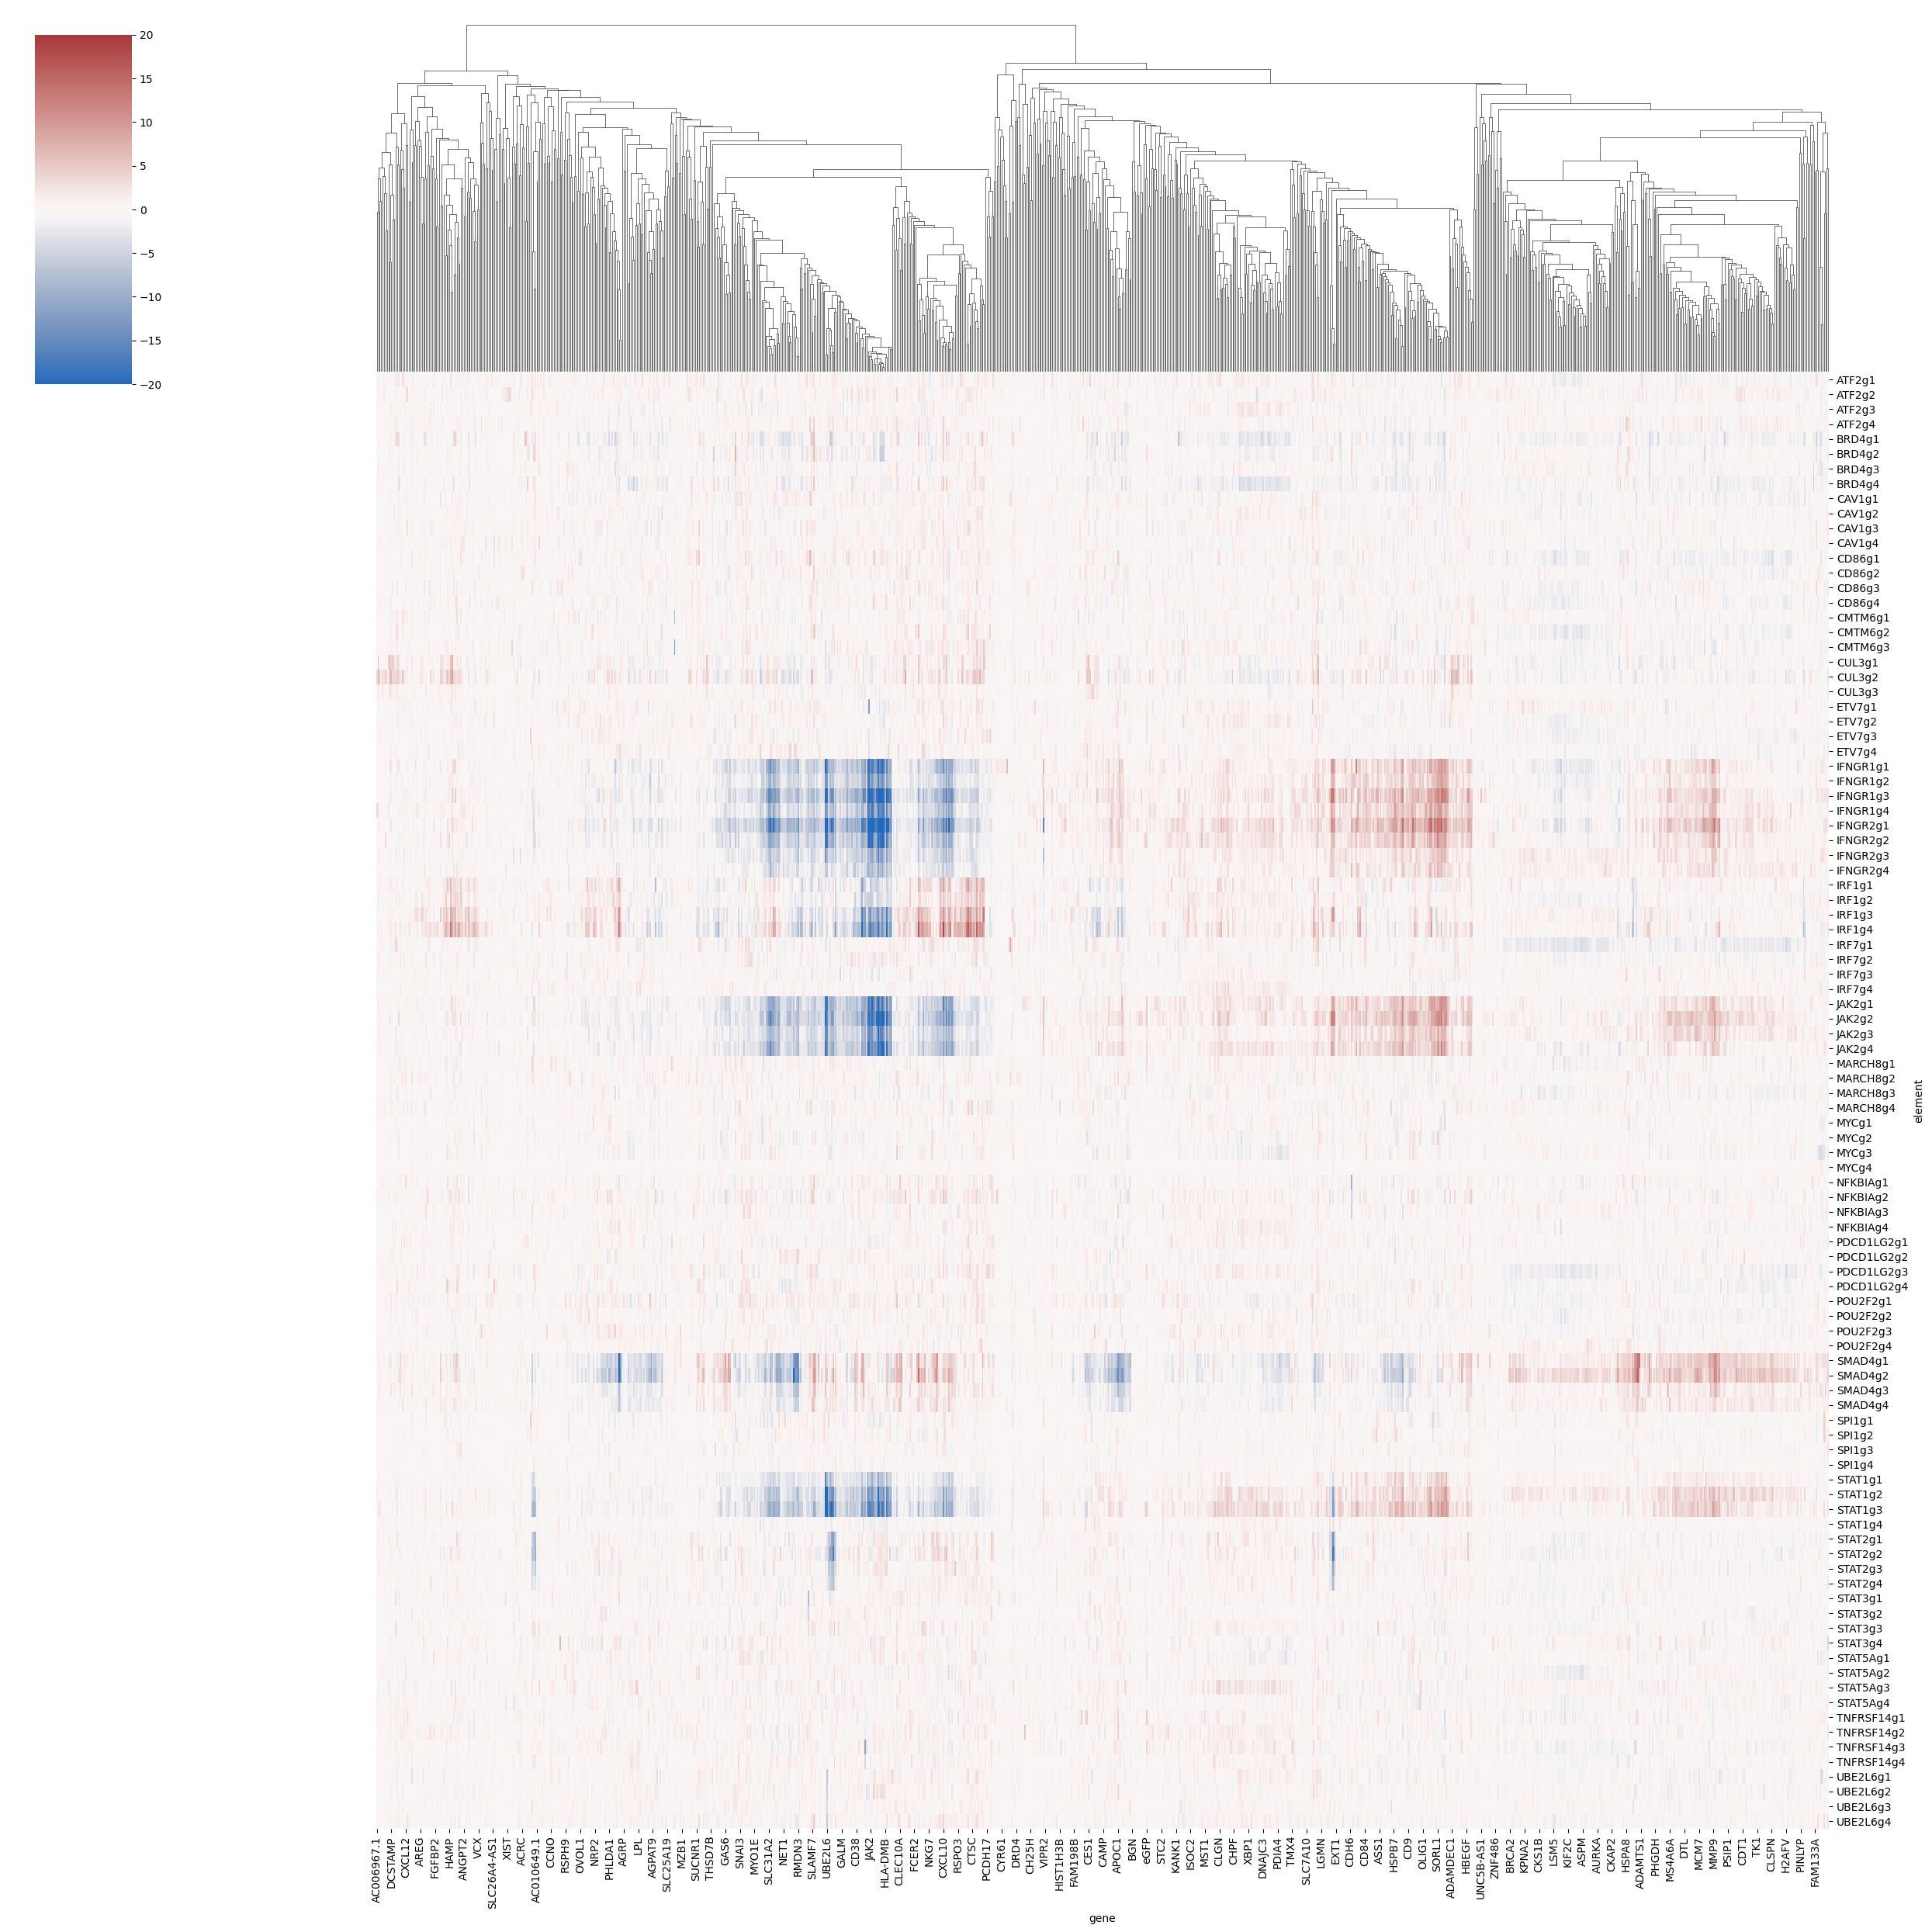

In [101]:

sns.clustermap(
    effects_df,
    center=0,
    vmax=20,
    vmin=-20,
    cmap="vlag",
    metric="cosine",
    figsize=(25, 25),
    # col_cluster=False,
    row_cluster=False
)

## Posterior simulations

In [61]:
# element_effects = 
from pyro.infer import Predictive

# predictive_svi = Predictive(model, guide=guide, num_samples=500)(X_, None)

# with pyro.condition(data={"element_effects": torch.zeros_like(guide.median()["element_effects"])}):

posterior_sample = dict(**guide.median())
for k, v in posterior_sample.items():
    posterior_sample[k]=v.unsqueeze(0)
    print(k, posterior_sample[k].shape)

log_gene_mean torch.Size([1, 1000])
log_gene_dispersion torch.Size([1, 1000])
multiplicative_noise torch.Size([1, 1000])
batch_effect torch.Size([1, 5, 1000])
cont_covariate_effect torch.Size([1, 3, 1000])
element_effects torch.Size([1, 98, 1000])


[]

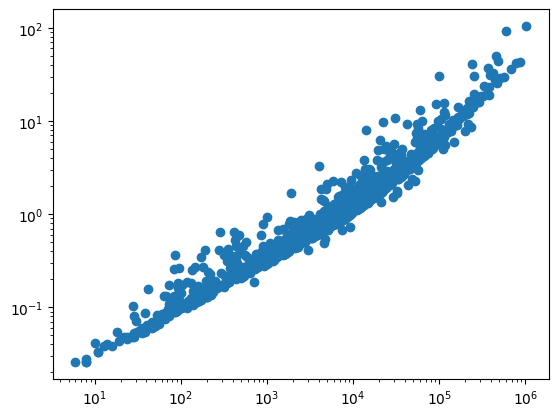

In [62]:
mean_variance = plt.scatter(mdata["rna"].X.sum(axis=0).A1, np.std(mdata["rna"].X.todense(),axis=0).A1)
plt.loglog()

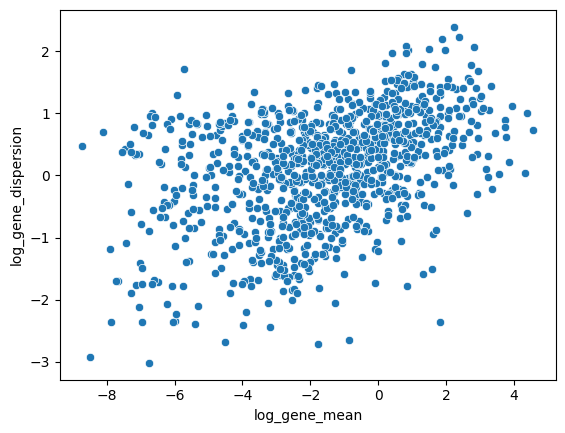

PearsonRResult(statistic=0.4233565612239627, pvalue=9.330465489855537e-45)

In [63]:
# # plt.scatter(posterior_sample["log_gene_mean"], posterior_sample["log_gene_dispersion"])
from scipy.stats import pearsonr

log_gene_mean = posterior_sample["log_gene_mean"].squeeze().numpy()
log_gene_dispersion = posterior_sample["log_gene_dispersion"].squeeze().numpy()
sns.scatterplot(x=log_gene_mean, y=log_gene_dispersion)
plt.ylabel("log_gene_dispersion")
plt.xlabel("log_gene_mean")

plt.show()

pearsonr(log_gene_mean, log_gene_dispersion)
# log_gene_mean
# plt.show()
# posterior_sample["log_gene_mean"].numpy()

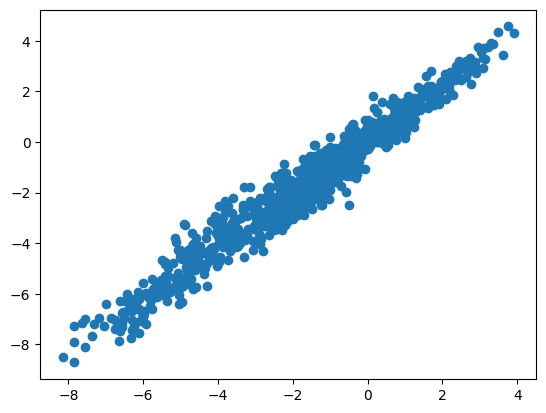

In [64]:
plt.scatter(np.log(mdata["rna"].X.mean(axis=0).A1), posterior_sample["log_gene_mean"])

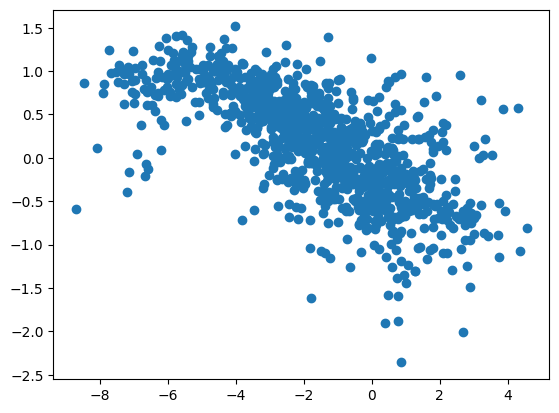

In [65]:
if "multiplicative_noise" in posterior_sample:
    # posterior_sample["multiplicative_noise"]=np.zeros(mdata["rna"].n_vars)
    plt.scatter(posterior_sample["log_gene_mean"], np.log(posterior_sample["multiplicative_noise"]))
    plt.show()


In [71]:
# sites_to_zero_out = ["element_effects", "pert_loadings"]
# for site in sites_to_zero_out:
#     posterior_sample[site] = torch.zeros_like(posterior_sample[site])

# posterior_sample["log_gene_mean"] = posterior_sample["log_gene_mean"] * 10
args, kwargs = model._get_data_subset()
args = [a.to(device) for a in args]
kwargs = {k: v.to(device) for k, v in kwargs.items()}
kwargs["X"] = None # sample counts instead of using observed
# kwargs["size_factor"] = torch.zeros_like(kwargs["size_factor"])  # no size factor


# serving_model = infer_discrete(model.module, first_available_dim=-4)
predictive_model = Predictive(model.module, posterior_samples=posterior_sample)
posterior_predictive = predictive_model(*args, **kwargs)["obs"].squeeze().numpy()
# posterior_sample = model.sample_posterior(num_samples=1, return_sites=["obs"])
posterior_predictive.shape

(20729, 1000)

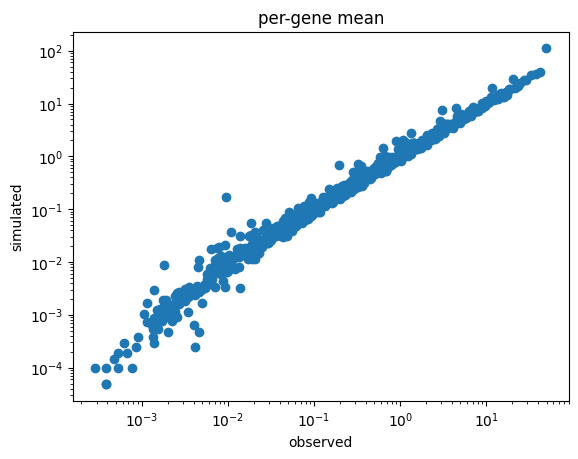

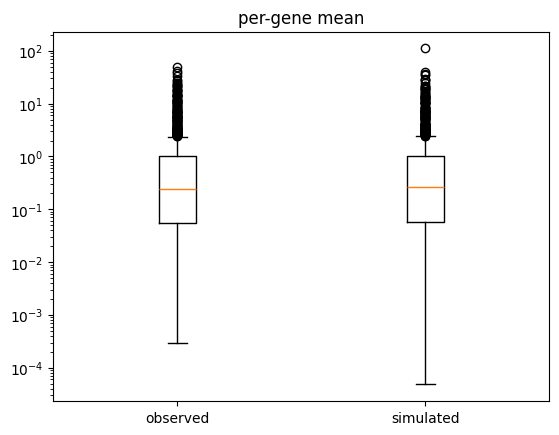

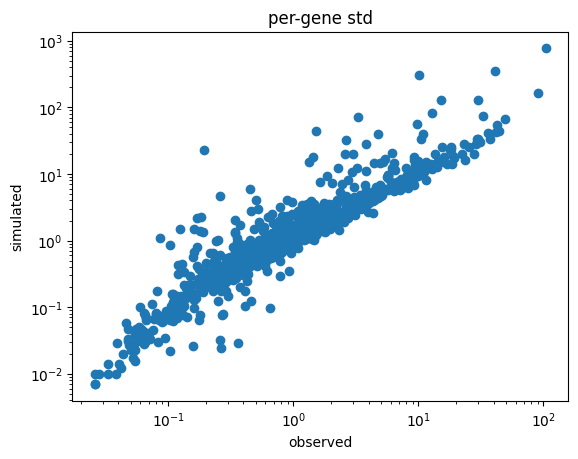

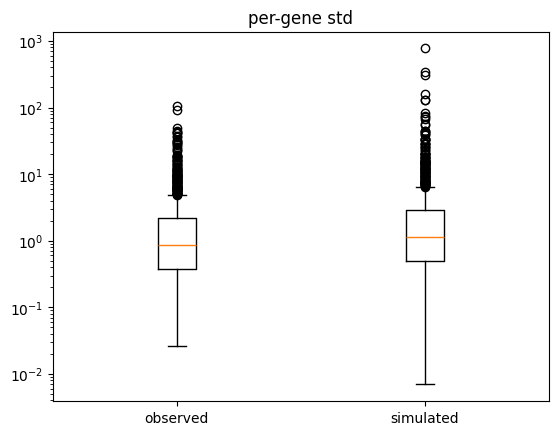

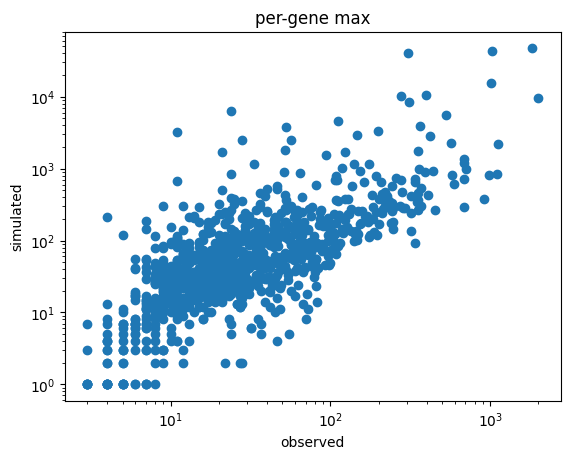

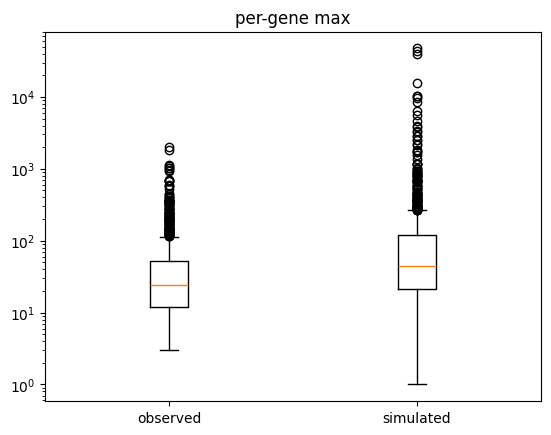

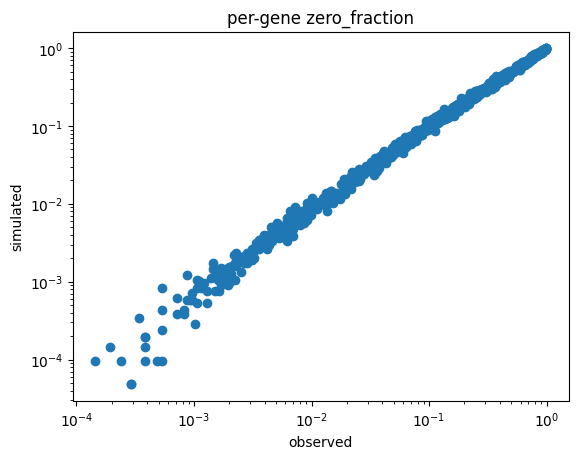

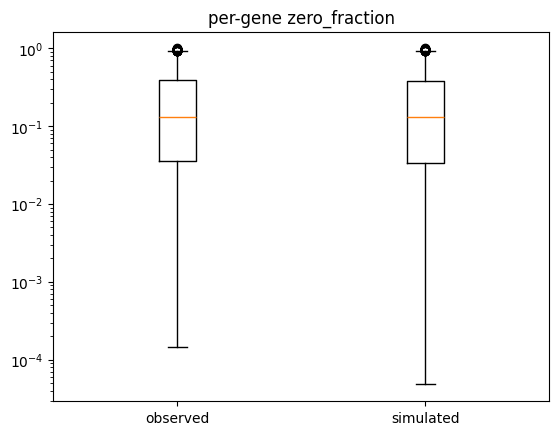

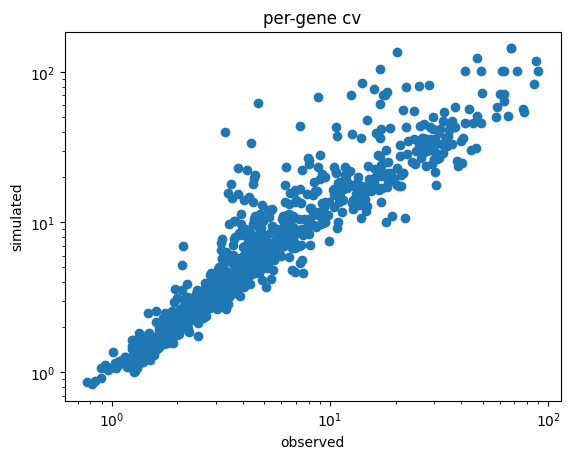

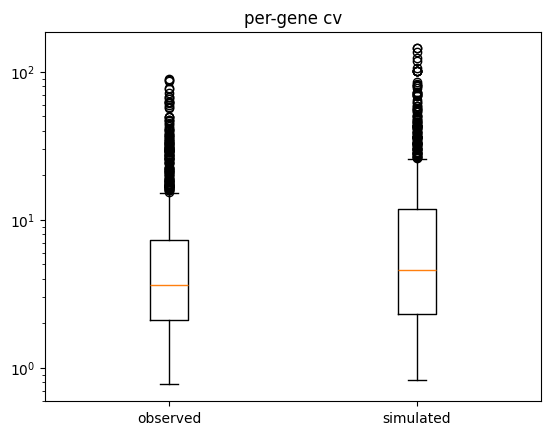

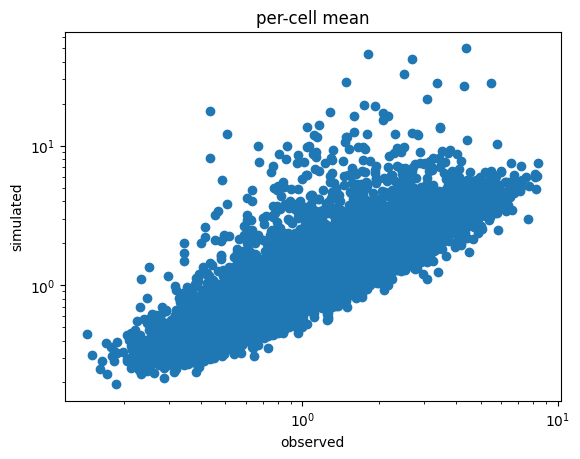

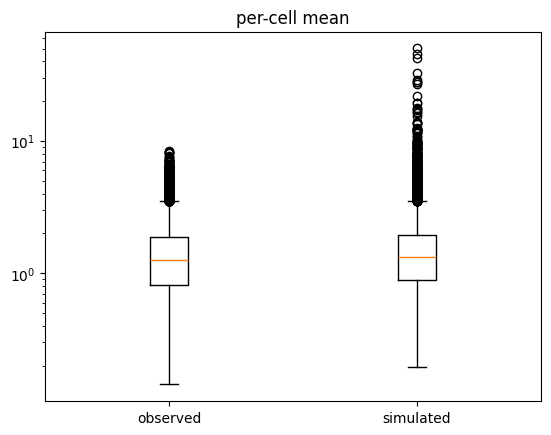

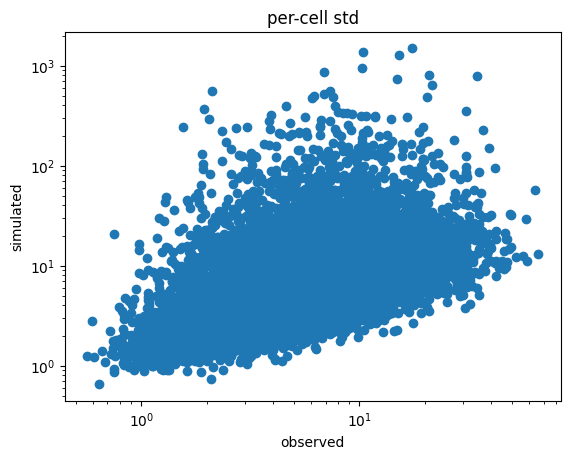

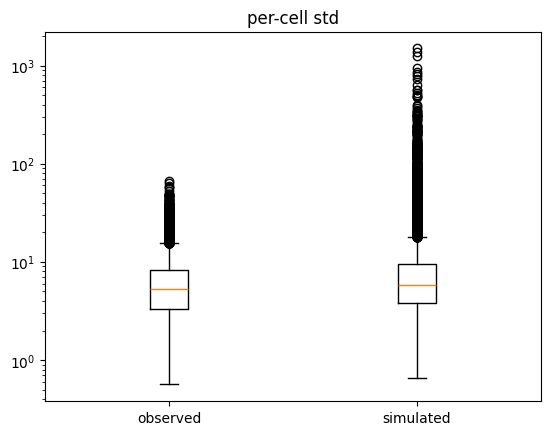

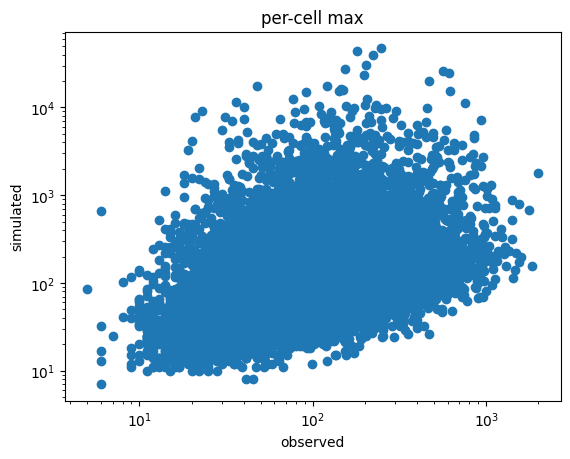

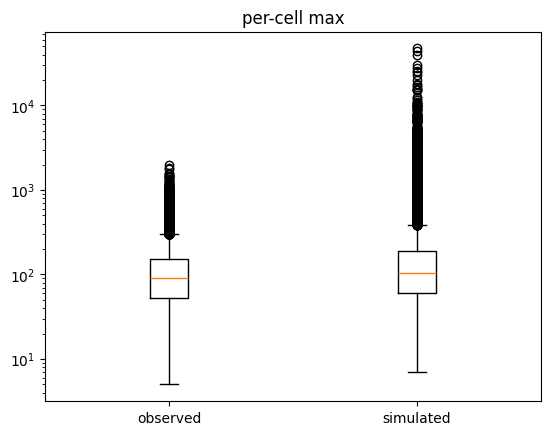

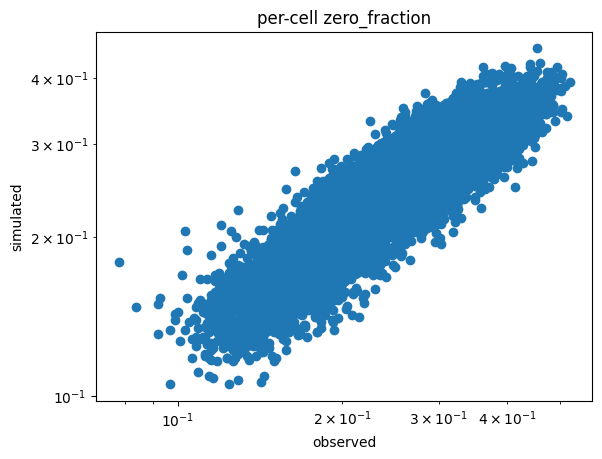

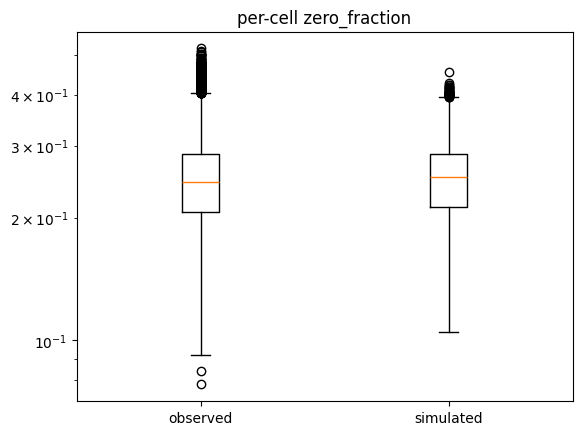

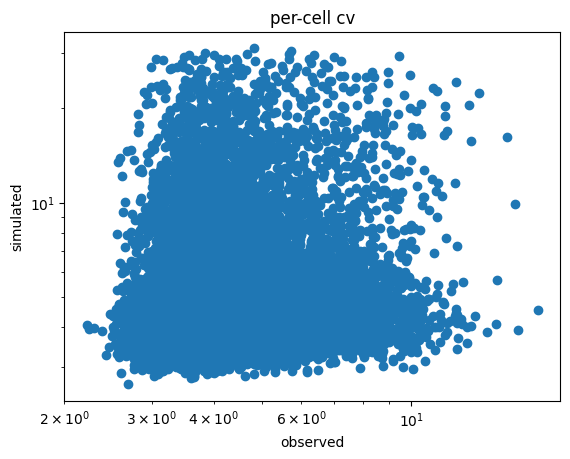

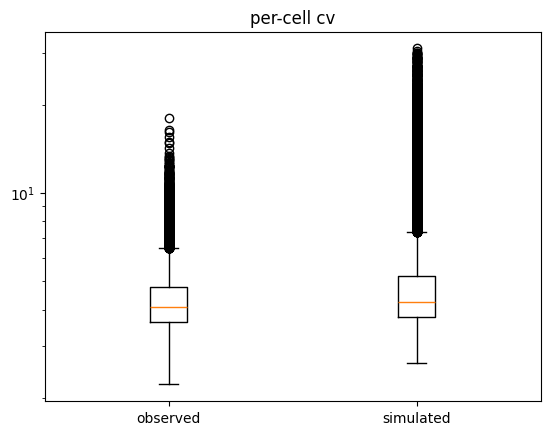

In [73]:
def compare_plot(x1, x2, func: np.mean, labels=["observed", "simulated"], axis=0, log_scale=True, plot_type="scatter"):
    x1_transform = func(x1, axis=axis)
    x2_transform = func(x2, axis=axis)
    if isinstance(x1, np.matrix):
        x1_transform = x1_transform.A1
    if isinstance(x2, np.matrix):
        x2_transform = x2_transform.A1
    stat_type = "gene" if axis == 0 else "cell"
    if plot_type == "scatter":
        plt.scatter(x1_transform, x2_transform)
        plt.xlabel(labels[0])
        plt.ylabel(labels[1])
        if log_scale:
            plt.loglog()

    elif plot_type == "boxplot":
        plt.boxplot([x1_transform, x2_transform])
        if log_scale:
            plt.semilogy()
        plt.xticks(ticks=[1,2],labels=labels)
    plt.title(f"per-{stat_type} {func.__name__}")
    plt.show()




def zero_fraction(x, axis=0):
    return np.mean(x > 0, axis=axis)


def cv(x, axis=0):
    return np.std(x, axis=axis) / np.mean(x, axis=axis)


for axis in [0, 1]:
    for func in [np.mean, np.std, np.max, zero_fraction, cv]:
        compare_plot(mdata["rna"].X.todense(), posterior_predictive, func, axis=axis)
        compare_plot(mdata["rna"].X.todense(), posterior_predictive, func, axis=axis, plot_type="boxplot")


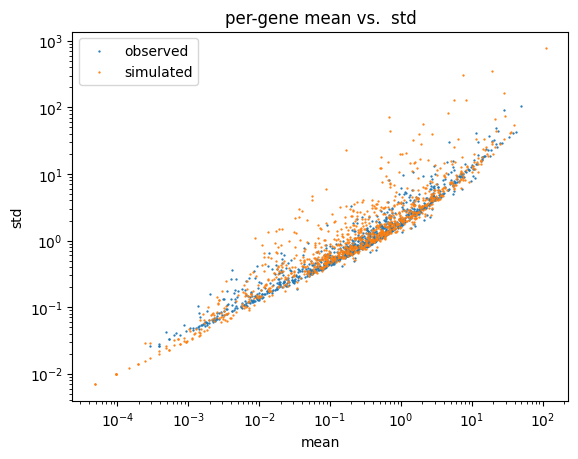

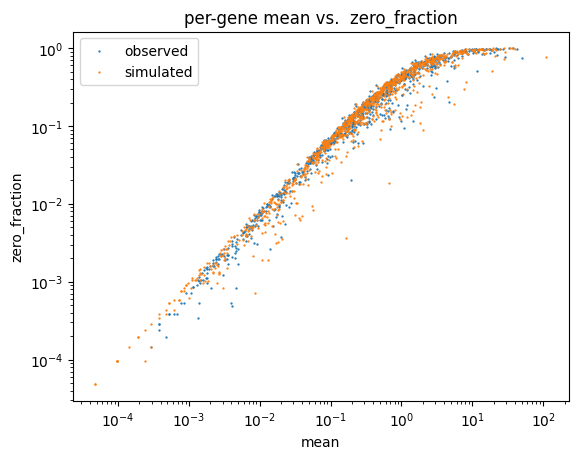

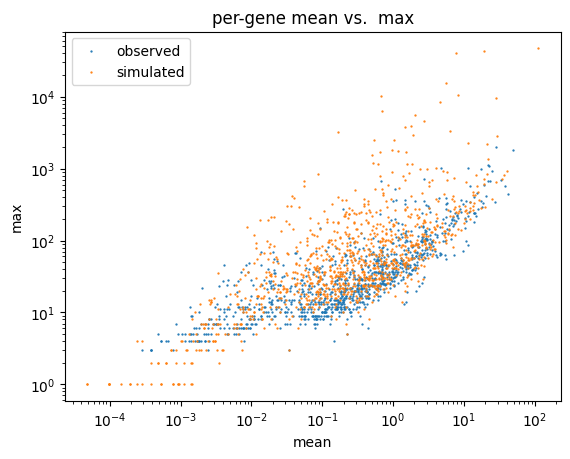

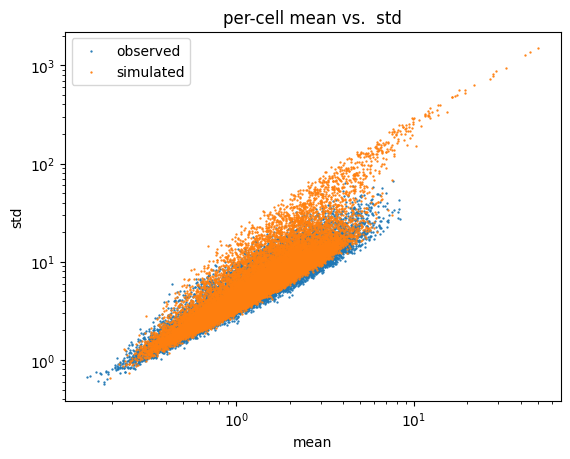

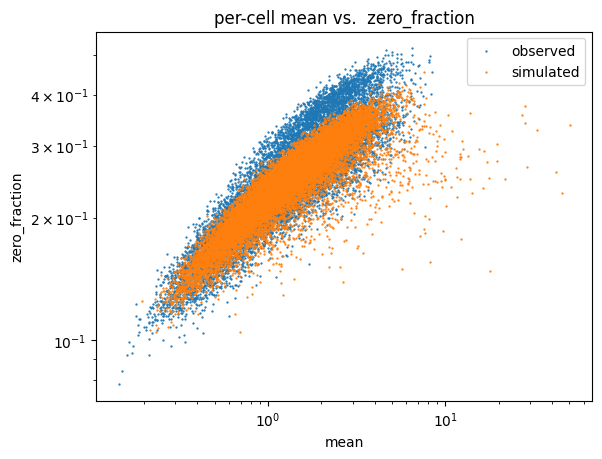

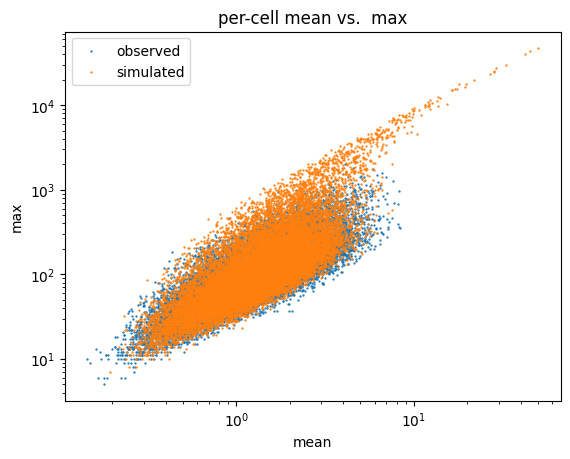

In [ ]:
def compare_plot_2d(
    x1, x2, func1, func2, labels=["observed", "simulated"], axis=0, log_scale=True, plot_type="scatter"
):
    x1_f1 = func1(x1, axis=axis)
    x2_f1 = func1(x2, axis=axis)
    x1_f2 = func2(x1, axis=axis)
    x2_f2 = func2(x2, axis=axis)
    if isinstance(x1, np.matrix):
        x1_f1 = x1_f1.A1
        x1_f2 = x1_f2.A1
    if isinstance(x2, np.matrix):
        x2_f1 = x2_f1.A1
        x2_f2 = x2_f2.A1
    stat_type = "gene" if axis == 0 else "cell"
    if plot_type == "scatter":
        plt.scatter(x1_f1, x1_f2, label=labels[0], s=0.4)
        plt.scatter(x2_f1, x2_f2, label=labels[1], s=0.4)
        plt.xlabel(func1.__name__)
        plt.ylabel(func2.__name__)
        if log_scale:
            plt.loglog()

    plt.title(f"per-{stat_type} {func1.__name__} vs.  {func2.__name__}")
    plt.legend()
    plt.show()

for axis in [0, 1]:
    for func1, func2 in [(np.mean, np.std), (np.mean, zero_fraction), (np.mean, np.max)]:
        compare_plot_2d(mdata["rna"].X.todense(), posterior_predictive, func1, func2, axis=axis)

# data_mean = mdata["rna"].X.mean(axis=0).A1
# posterior_pred_mean = posterior_predictive.mean(axis=0)
# plt.scatter(data_mean, posterior_pred_mean)
# plt.title("per gene mean")
# plt.loglog()

<Axes: >

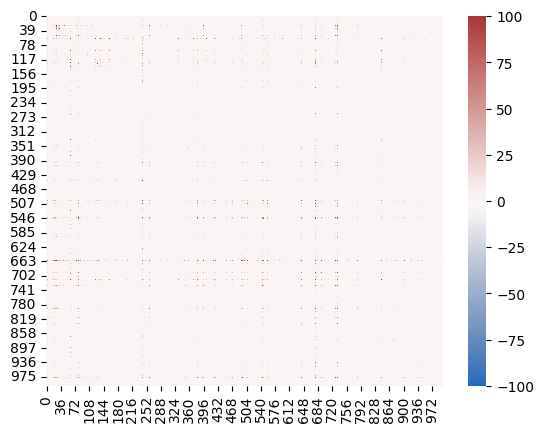

In [75]:
cov_obs = np.cov(mdata["rna"].X.todense(), rowvar=False)
cov_sim = np.cov(posterior_predictive, rowvar=False)
sns.heatmap(cov_obs, center=0, cmap="vlag", vmax=100, vmin=-100)

<Axes: >

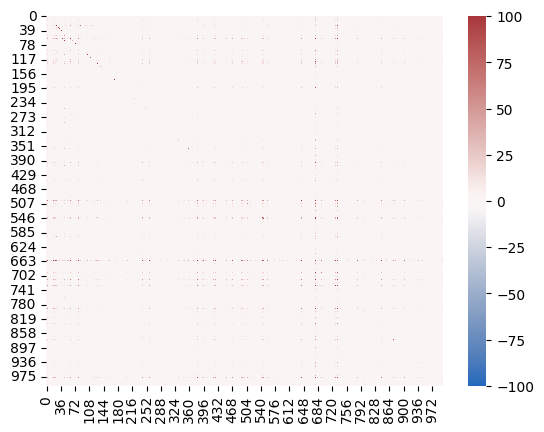

In [76]:
sns.heatmap(cov_sim, center=0, cmap="vlag", vmax=100, vmin=-100)

In [108]:

plot_genes = [g for g in list(cis_effects["element"]) if g != "control"]
# plot_genes

In [79]:
# effect_variance = effects_df.var(axis=0)
effect_variance = effects_df_long.groupby("gene")["loc"].var()
# effect_variance = (effects_df.abs() > 5).sum(axis=0)
# effect_variance = (effects_df.loc[["STAT3", "STAT5A", "CAV1", "CD86"]].abs()).sum(
#     axis=0
# )
hvgs = effect_variance.nlargest(50).index.tolist()
hvgs
# effects_df[effects_df["gene"].isin(hvgs)]


['CXCL11',
 'CXCL10',
 'CXCL9',
 'MMP9',
 'RP11-742B18.1',
 'OSM',
 'C1QB',
 'STEAP4',
 'IGFBP3',
 'IDO1',
 'C1QC',
 'HLA-DPA1',
 'THBS1',
 'MYLK',
 'IRG1',
 'RSPO3',
 'SOCS1',
 'HLA-DRA',
 'CCL7',
 'IL27',
 'VAMP5',
 'SPARC',
 'HLA-DPB1',
 'KRT86',
 'APOL4',
 'IL18BP',
 'TBX21',
 'VCAM1',
 'IGFBP5',
 'RP4-799D16.1',
 'CHI3L2',
 'TESC',
 'CCL8',
 'IGF1',
 'FAM111B',
 'PRF1',
 'SAA1',
 'ITK',
 'IL32',
 'AKR1C2',
 'ANKRD22',
 'CCL4L2',
 'NTRK1',
 'HAPLN3',
 'CXCL3',
 'RP11-701P16.5',
 'GBP7',
 'HLA-DMB',
 'RP11-184M15.1',
 'ID3']

In [80]:
# plt.scatter(guide.median()["gene_mean"].cpu().log(), guide.median()["dispersion"].cpu().log(), alpha=0.1)

In [81]:
if not smoke_test:
    pyro.get_param_store().save("params.save")

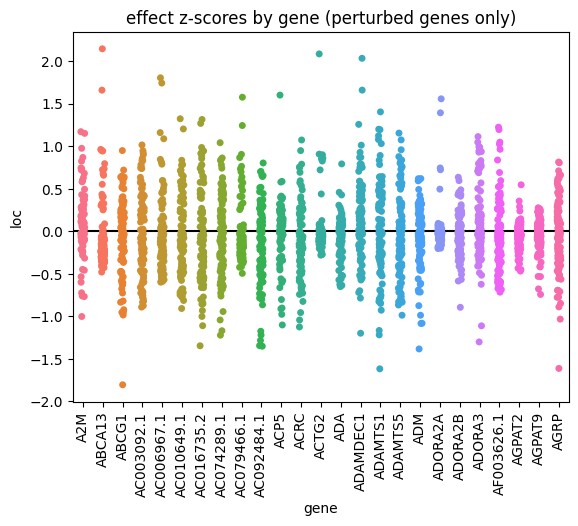

In [82]:
n_plot_genes = 25
sns.stripplot(effects_df.iloc[:, :n_plot_genes])
# sns.stripplot(effects_df[[g for g in plot_genes if g in effects_df.columns]])
#
plt.axhline(0, color="black")
plt.xticks(rotation=90)
plt.ylabel("loc")
plt.title("effect z-scores by gene (perturbed genes only)")
plt.show()

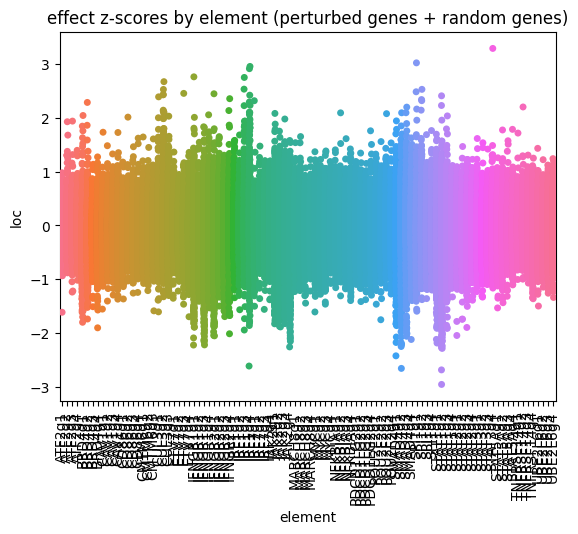

In [83]:
sns.stripplot(effects_df.T, alpha=1)
plt.xticks(rotation=90)
plt.axhline(0, color="black")
plt.ylabel("loc")
plt.xlabel("element")
plt.title("effect z-scores by element (perturbed genes + random genes)")
plt.show()

## Factor Analysis

In [ ]:
# if len(elements)!=model.module.n_perturbations:
    # elements = mdata["grna"].var_names
if "pert_factors" in model.module.guide.median():
    elements=targeting_guides
    pert_factors = pd.DataFrame(
        model.module.guide.median()["pert_factors"].squeeze(),
        columns=elements,
    )
    sns.clustermap(pert_factors, cmap="vlag", figsize=(30, 6), row_cluster=False, col_cluster=False, center=0, vmin=-1, vmax=1)
    pert_factors



In [ ]:
# find the factors that are most loaded up for each perturbed gene
if "pert_factors" in model.module.guide.median():

    pert_factors_anno = (
        pert_factors.melt(ignore_index=False, var_name="guide_id")
        .reset_index(names="factor")
        .merge(mdata["grna"].var.reset_index(names="guide_id"))
    )
    pert_factors_avg = pert_factors_anno.groupby(["Gene", "factor"])["value"].mean().reset_index()


    sns.histplot(pert_factors_avg["value"], binwidth=0.1)
    sns.clustermap(
        pert_factors_avg.pivot(index="factor", columns="Gene", values="value"),
        cmap="vlag",
        figsize=(30, 6),
        row_cluster=False,
        # col_cluster=False,
        center=0,
        vmin=-1,
        vmax=1,
    )
    pert_factors_avg.query("abs(value)>0.2").sort_values(["factor"])


In [ ]:
if "pert_factors" in model.module.guide.median():

    pert_loadings = pd.DataFrame(
        model.module.guide.median()["pert_loadings"].squeeze(),
        columns=mdata["rna"].var_names,
    )

    pert_loadings


In [ ]:
if "pert_factors" in model.module.guide.median():

    n_genes_per_factor = 5
    top_genes_per_factor_df = (
        pert_loadings.transform(abs)
        .melt(ignore_index=False)
        .reset_index(names="factor")
        .sort_values("value")
        .groupby("factor")
        .tail(n_genes_per_factor)
        .sort_values("factor")
    )
    top_genes_per_factor_df

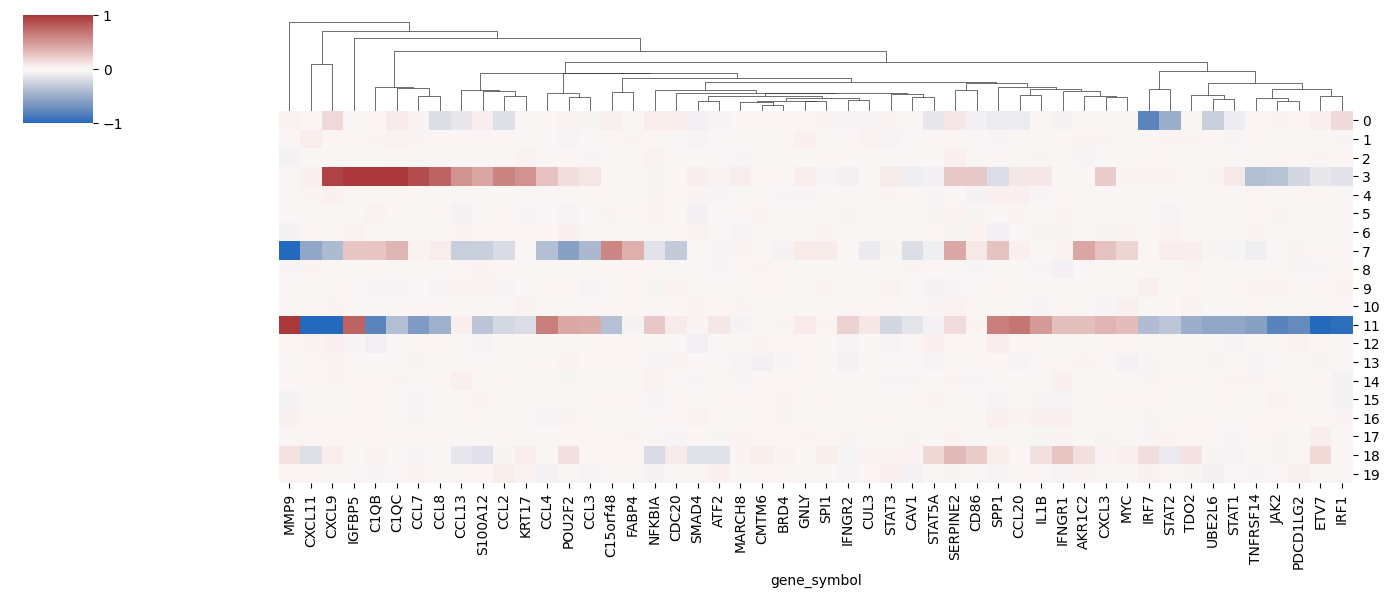

In [ ]:
top_genes = (np.abs(pert_loadings)).max().nlargest(100).index
# top_genes = pert_loadings.melt().groupby("")
# top_genes = top_genes_df["gene_symbol"]

pert_loadings_subset = pert_loadings.loc[:, top_genes]
sns.clustermap(
    pert_loadings_subset, cmap="vlag", row_cluster=False, figsize=(14, 6), center=0, vmin=-1, vmax=1
)


In [ ]:
# top_genes = pert_loadings.melt().groupby("")
# top_genes = top_genes_df["gene_symbol"]

# pert_loadings_subset = pert_loadings.loc[:, top_genes]
# sns.clustermap(pert_loadings_subset, cmap="vlag", row_cluster=False, figsize=(14, 6), center=0, vmin=-1, vmax=1)


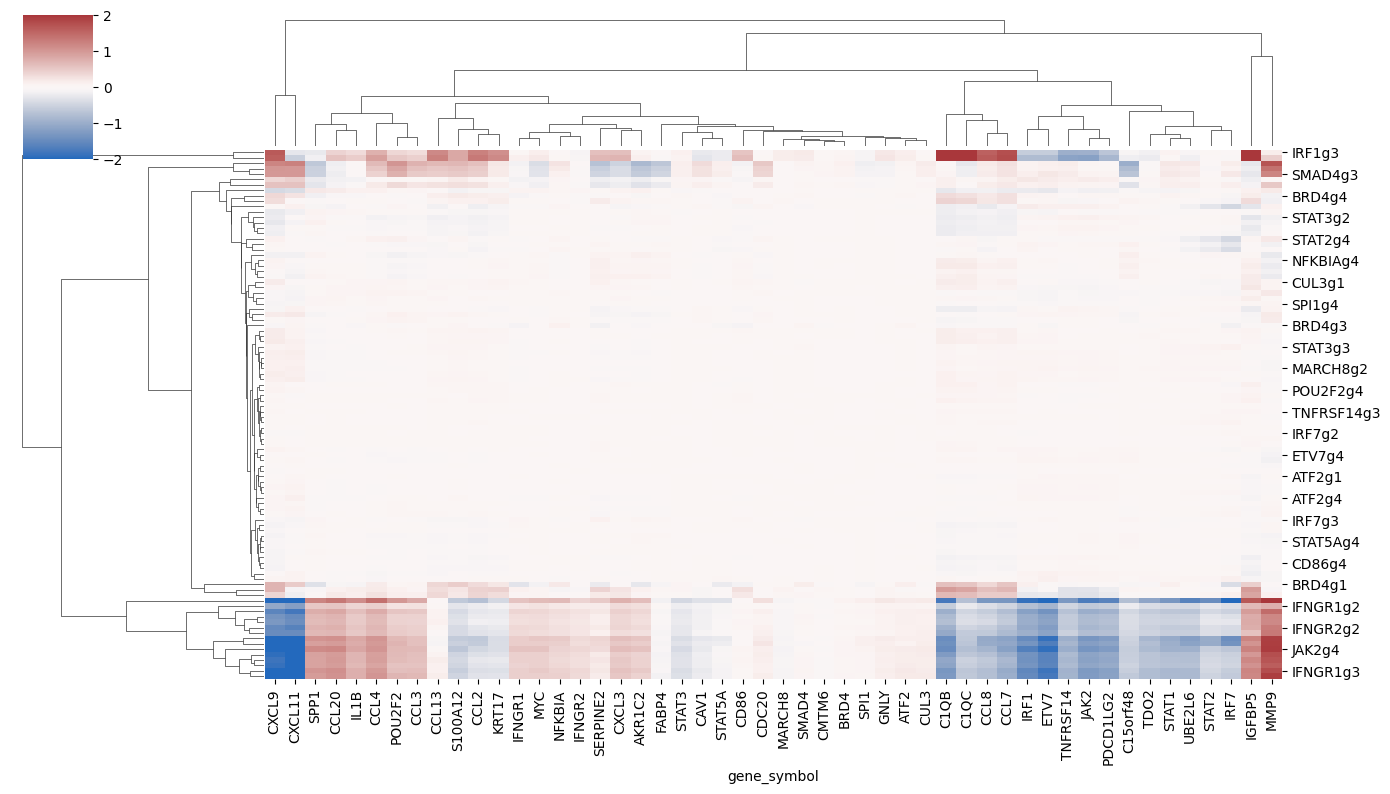

In [ ]:
reconstructed_effects = pd.DataFrame(
    pert_factors.values.T @ pert_loadings.values,
    index=elements,
    columns=mdata["rna"].var_names,
)
sns.clustermap(reconstructed_effects, center=0, cmap="vlag", figsize=(14, 8),vmin=-2,vmax=2)

In [ ]:
# reconstructed_effects.loc["CUL3"].sort_values().tail(20)

In [ ]:
# effects_df = effects
# sns.stripplot(guide.median()["effect"])
# # print(n_guides)
# from numpy import median

# median_effect = guide.median()["trans_effect"].detach().cpu()
# low_effect, high_effect = guide.quantiles([0.159, 0.841])["trans_effect"].detach().cpu()
# sigma_effect = high_effect - low_effect
# z_score_effect = median_effect / sigma_effect

# effects_df = pd.DataFrame(
#     effects,
#     # z_score_effect,
#     columns=adata_subset.var_names,
#     index=elements,
# )
# effects_df

# effects_df = pd.DataFrame(
#     median_effect,
#     columns=adata_subset.var_names,
#     index=list(element_mapping.keys())[:n_elements],
# )
# effects_df
